In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.classifier import ConfusionMatrix
from sklearn.model_selection import train_test_split
from sklearn import preprocessing,metrics
plt.style.use('seaborn-v0_8')
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)


# Reading the Dataset and Doing Initial Analysis

In [2]:
import os
from pathlib import Path
import pandas as pd

# Paths
DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/ColabProjects/csv")
DRIVE_CSV_PATH = DRIVE_PROJECT_DIR / "Cancer_Data.csv"

# Temporary runtime path: upload the file here when Drive is unavailable
RUNTIME_CSV_PATH = Path("./Cancer_Data.csv")

csv_path = None

# Try persistent Google Drive storage first
try:
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)
    DRIVE_PROJECT_DIR.mkdir(parents=True, exist_ok=True)

    if DRIVE_CSV_PATH.exists():
        csv_path = DRIVE_CSV_PATH
        print(f"Using Google Drive file: {csv_path}")
    else:
        print(f"Drive mounted, but CSV was not found: {DRIVE_CSV_PATH}")

except Exception as e:
    print(f"Google Drive mount failed: {type(e).__name__}: {e}")
    print("Trying the temporary Colab runtime instead...")

# Fall back to the current Colab runtime
if csv_path is None:
    if RUNTIME_CSV_PATH.exists():
        csv_path = RUNTIME_CSV_PATH
        print(f"Using temporary runtime file: {csv_path}")
    else:
        raise FileNotFoundError(
            "Cancer_Data.csv was not found in either location:\n"
            f"1. Google Drive: {DRIVE_CSV_PATH}\n"
            f"2. Colab runtime: {RUNTIME_CSV_PATH}\n\n"
            "Upload the file to the current runtime with:\n"
            "from google.colab import files\n"
            "files.upload()"
        )

# Read the CSV
try:
    df = pd.read_csv(csv_path)
    print(f"CSV loaded successfully. Shape: {df.shape}")
    display(df.head())

except pd.errors.EmptyDataError:
    raise ValueError(f"The CSV file is empty: {csv_path}")

except pd.errors.ParserError as e:
    raise ValueError(
        f"The CSV format could not be parsed: {csv_path}\n"
        f"Details: {e}"
    )

except Exception as e:
    raise RuntimeError(
        f"Could not load CSV file: {csv_path}\n"
        f"Details: {type(e).__name__}: {e}"
    )

Mounted at /content/drive
Using Google Drive file: /content/drive/MyDrive/ColabProjects/csv/Cancer_Data.csv
CSV loaded successfully. Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df = df.drop(columns = ['id','Unnamed: 32'])
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [5]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


> **Dividing the dataset into 3 datasets for easier analysis**

In [6]:
df_viz1 = df.iloc[:,1:11]
df_viz2 = df.iloc[:,11:21]
df_viz3 = df.iloc[:,21:-1]
df_viz1['diagnosis'] = df.diagnosis
df_viz2['diagnosis'] = df.diagnosis
df_viz3['diagnosis'] = df.diagnosis

# Analyis on the first part

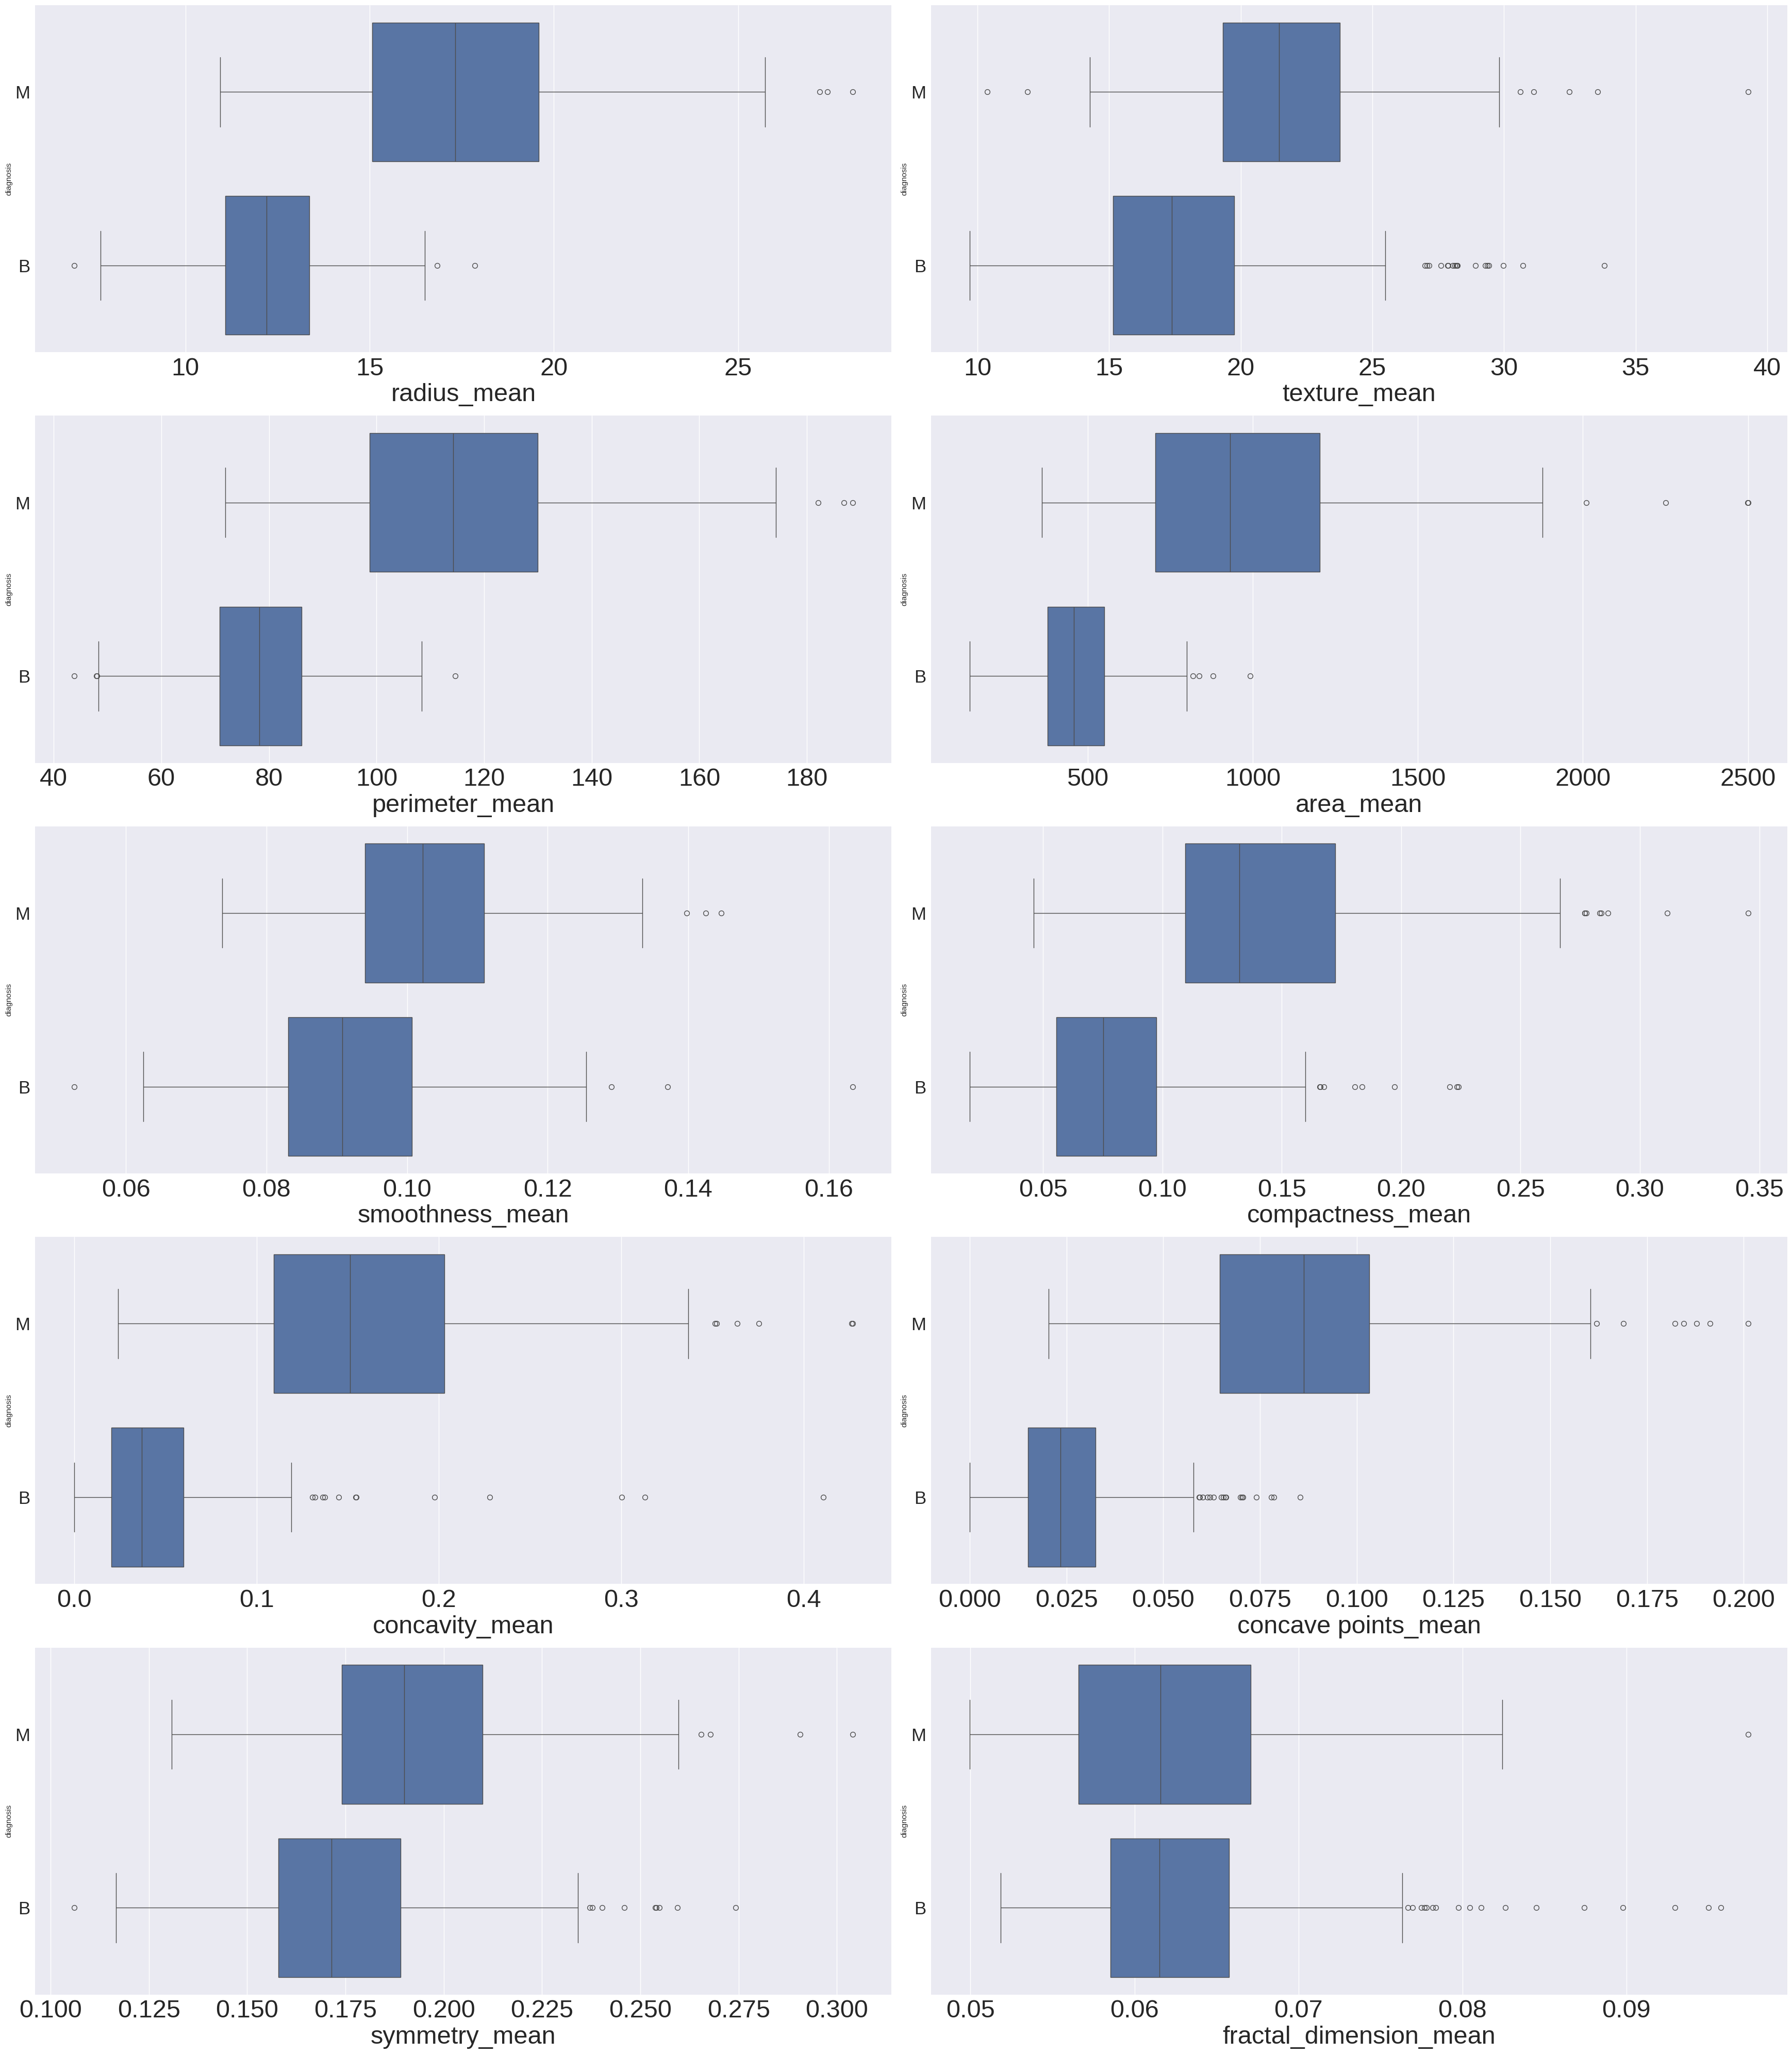

In [7]:
fig,axs = plt.subplots(ncols =2 ,nrows =5 ,figsize = (35,40),dpi= 100)
axs = axs.flatten()
for i,col in enumerate(df_viz1.drop(columns = 'diagnosis').columns) :
    sns.boxplot(x = col,y='diagnosis',data = df_viz1 , ax=axs[i])
    axs[i].set_xlabel(col,fontsize=35)
    axs[i].tick_params(axis= 'x',labelsize = 35)
    axs[i].tick_params(axis= 'y',labelsize = 25)

plt.tight_layout()
plt.show()

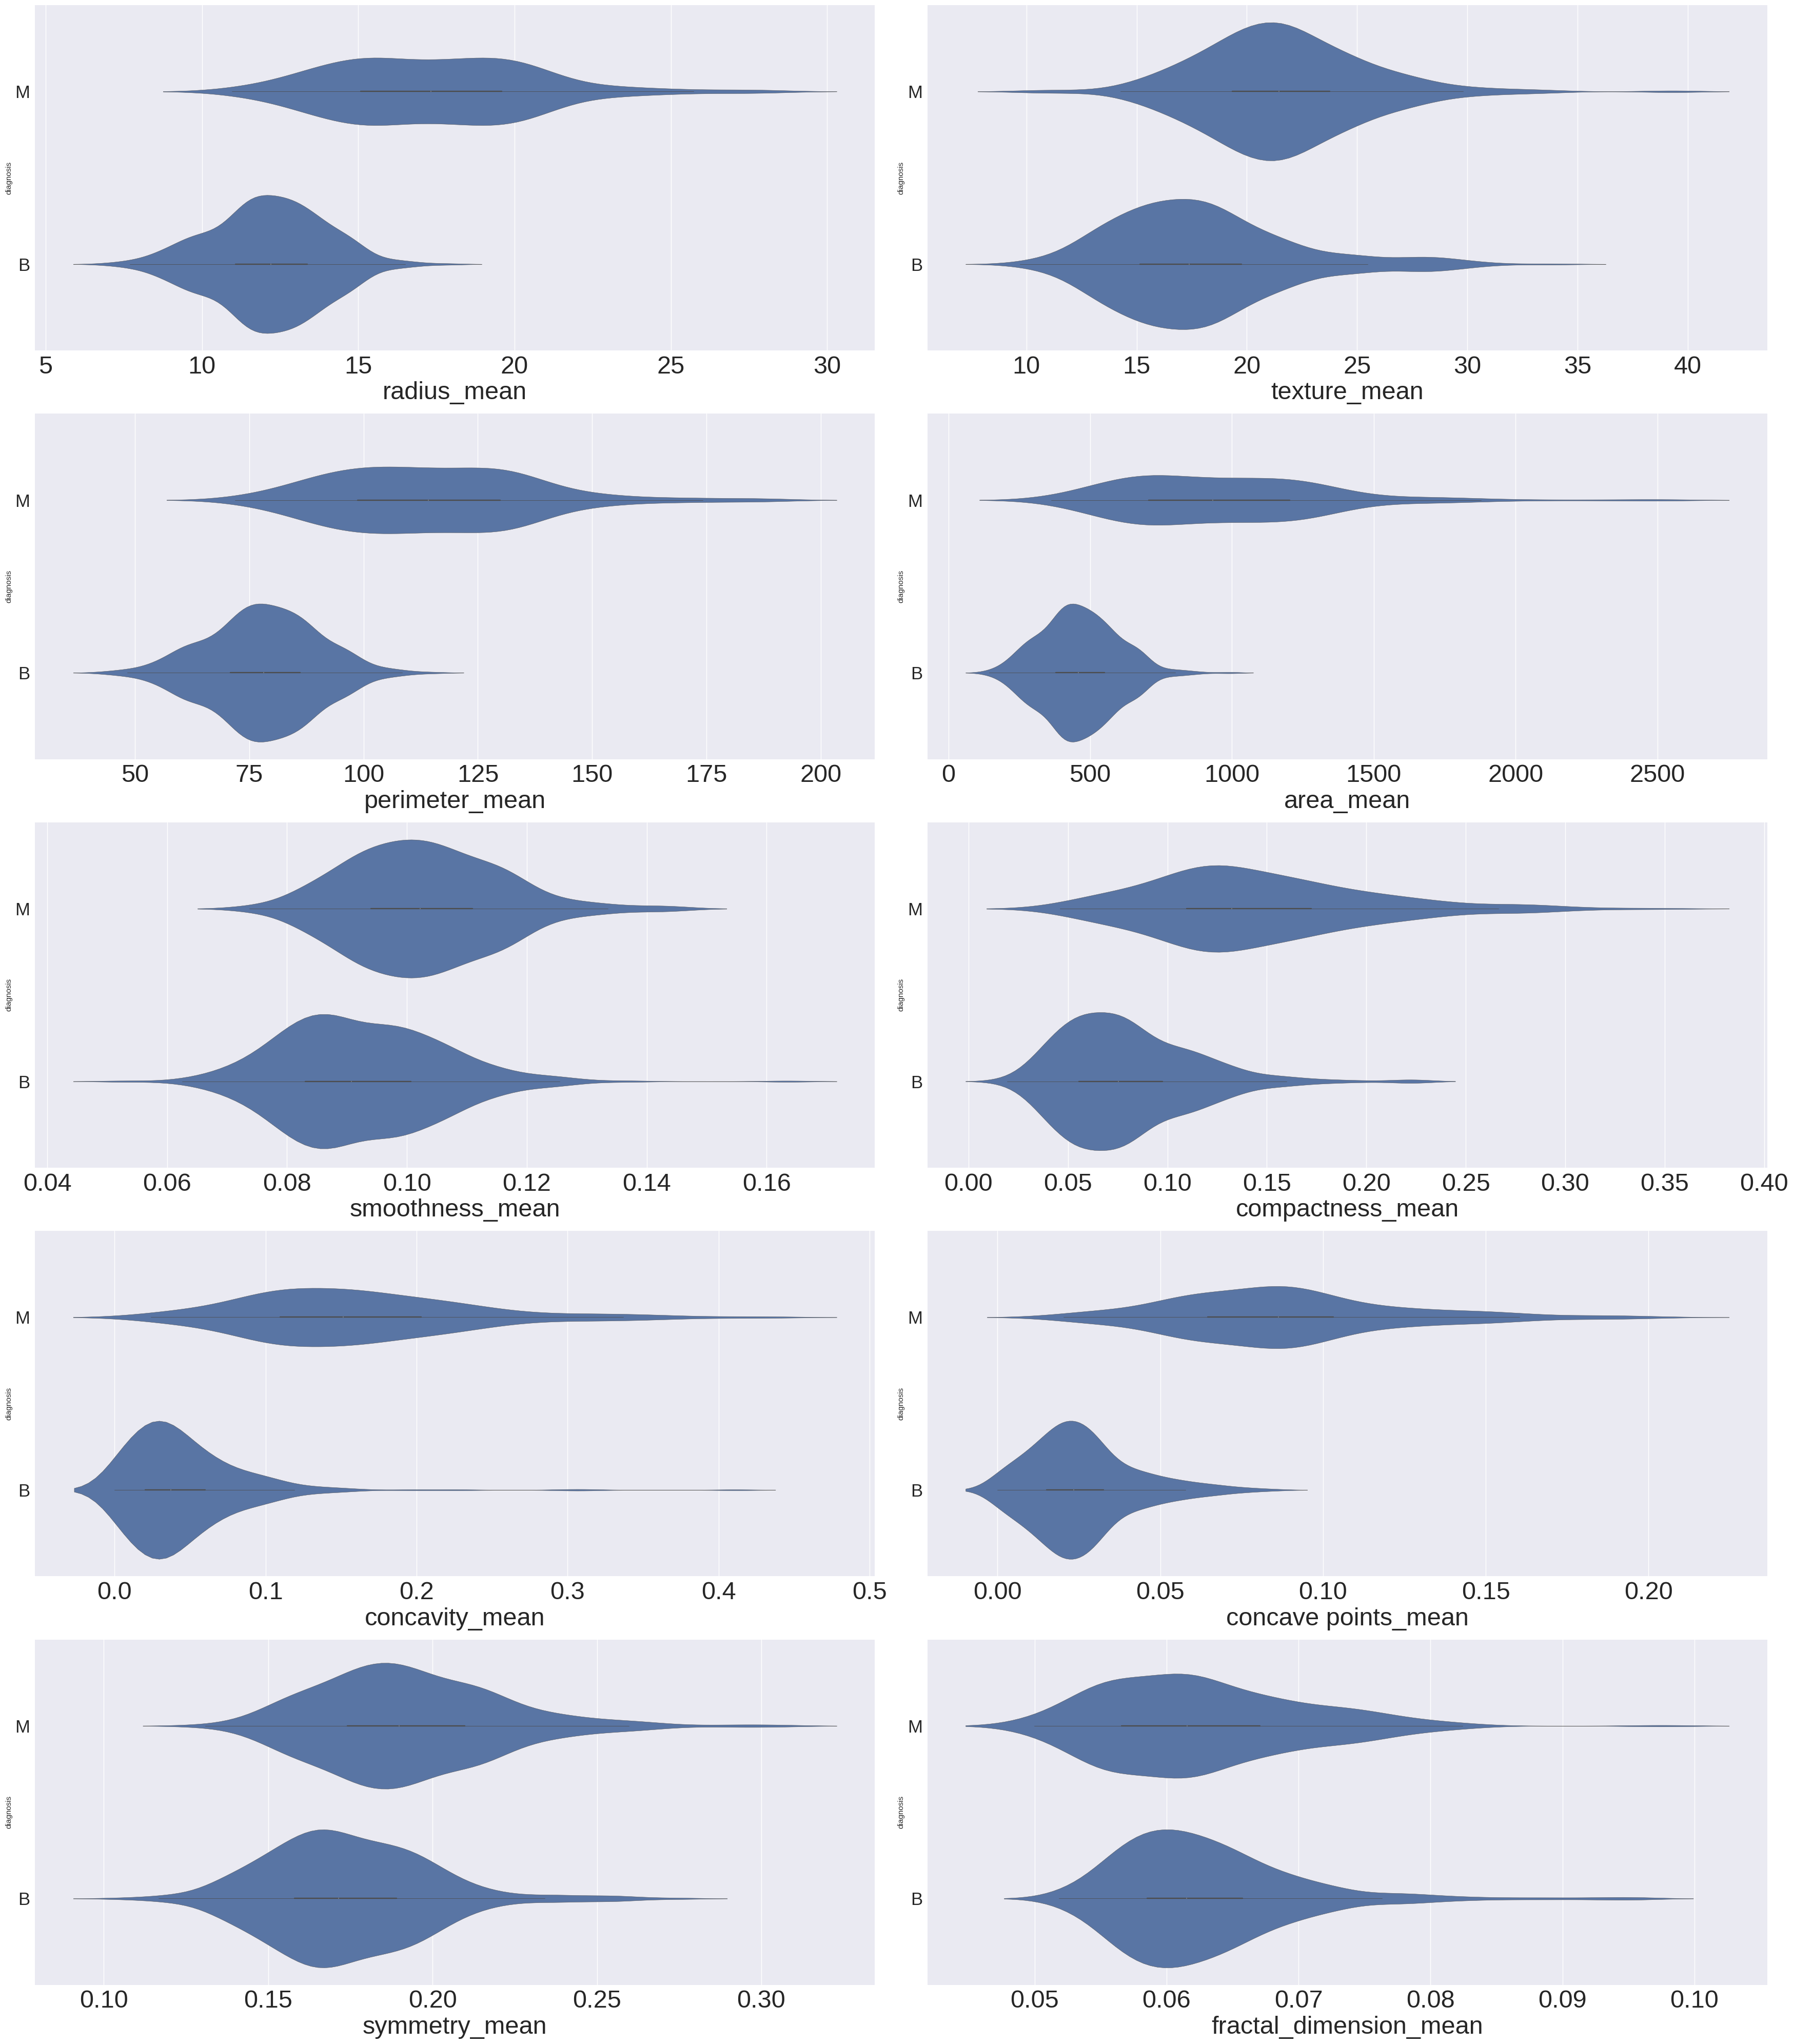

In [8]:
fig,axs = plt.subplots(ncols =2 ,nrows =5 ,figsize = (35,40),dpi= 100)
axs = axs.flatten()
for i,col in enumerate(df_viz1.drop(columns = 'diagnosis').columns) :
    sns.violinplot(x = col,y='diagnosis',data = df_viz1, ax=axs[i])
    axs[i].set_xlabel(col,fontsize=35)
    axs[i].tick_params(axis= 'x',labelsize = 35)
    axs[i].tick_params(axis= 'y',labelsize = 25)

plt.tight_layout()
plt.show()

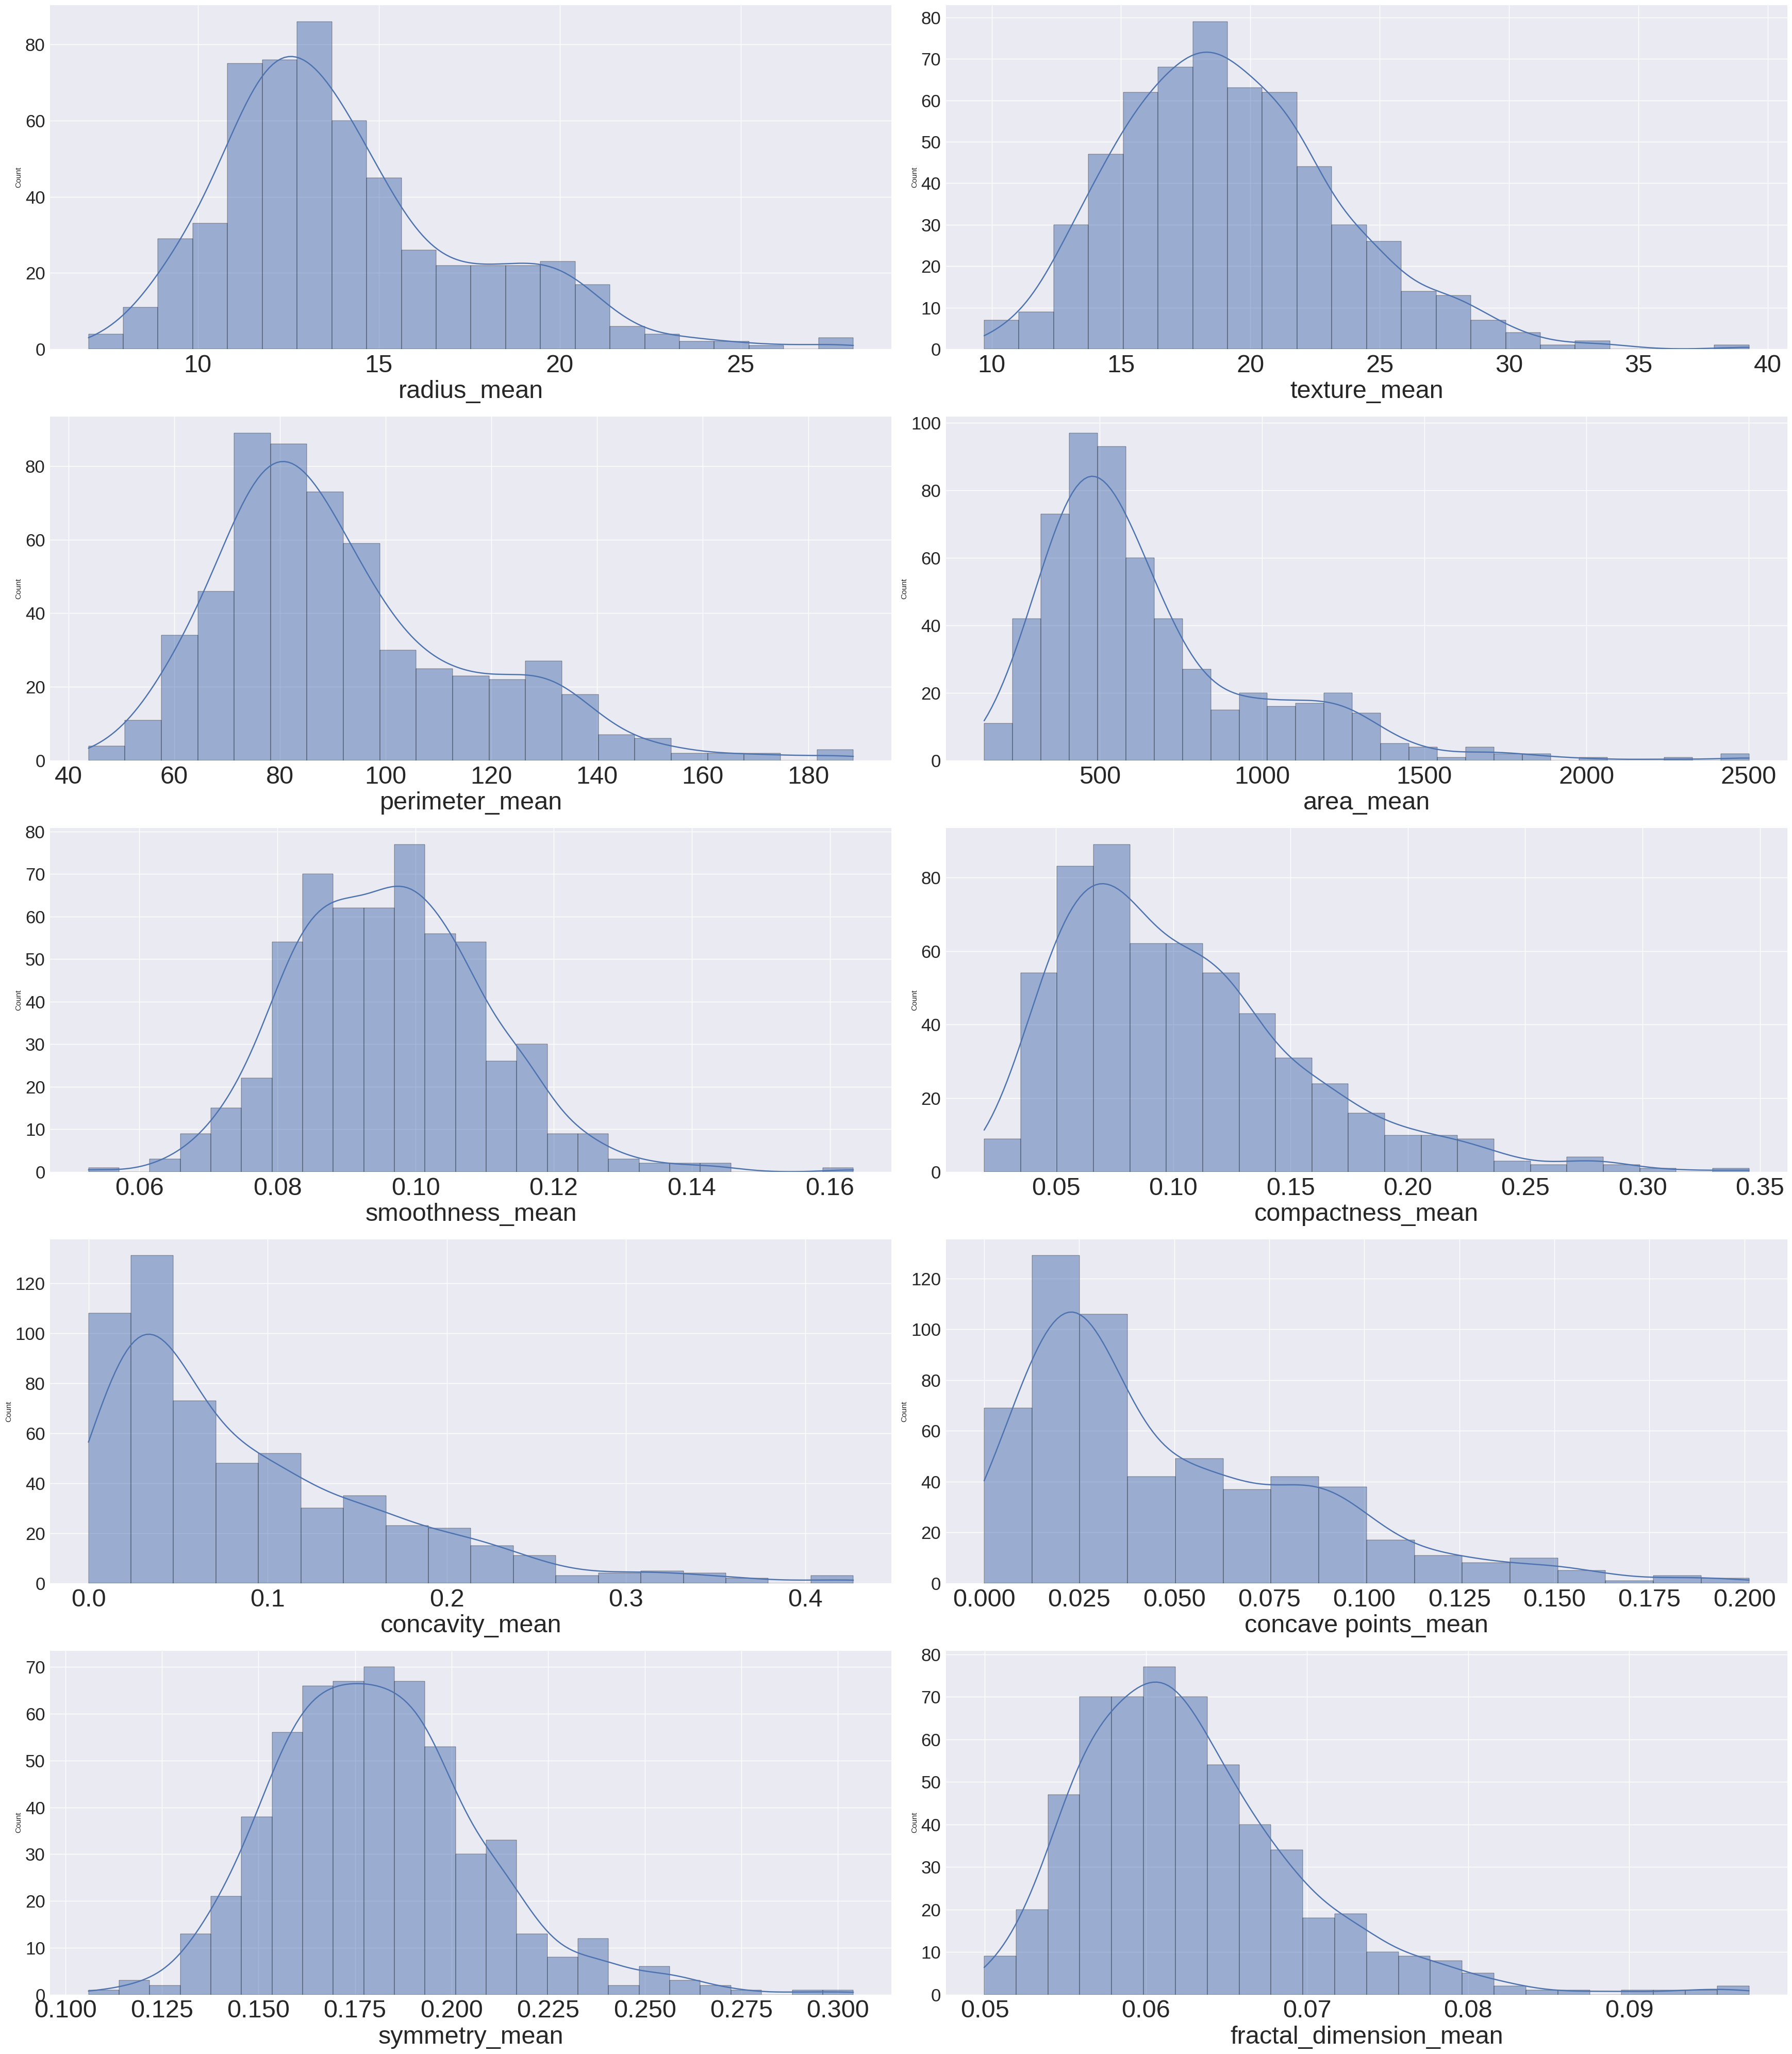

In [9]:
fig,axs = plt.subplots(ncols =2 ,nrows =5 ,figsize = (35,40),dpi= 100)
axs = axs.flatten()
for i,col in enumerate(df_viz1.drop(columns = 'diagnosis').columns) :
    sns.histplot(x = col,data = df_viz1 ,kde=True, ax=axs[i])
    axs[i].set_xlabel(col,fontsize=35)
    axs[i].tick_params(axis= 'x',labelsize = 35)
    axs[i].tick_params(axis= 'y',labelsize = 25)

plt.tight_layout()
plt.show()

# Analyis on the second part

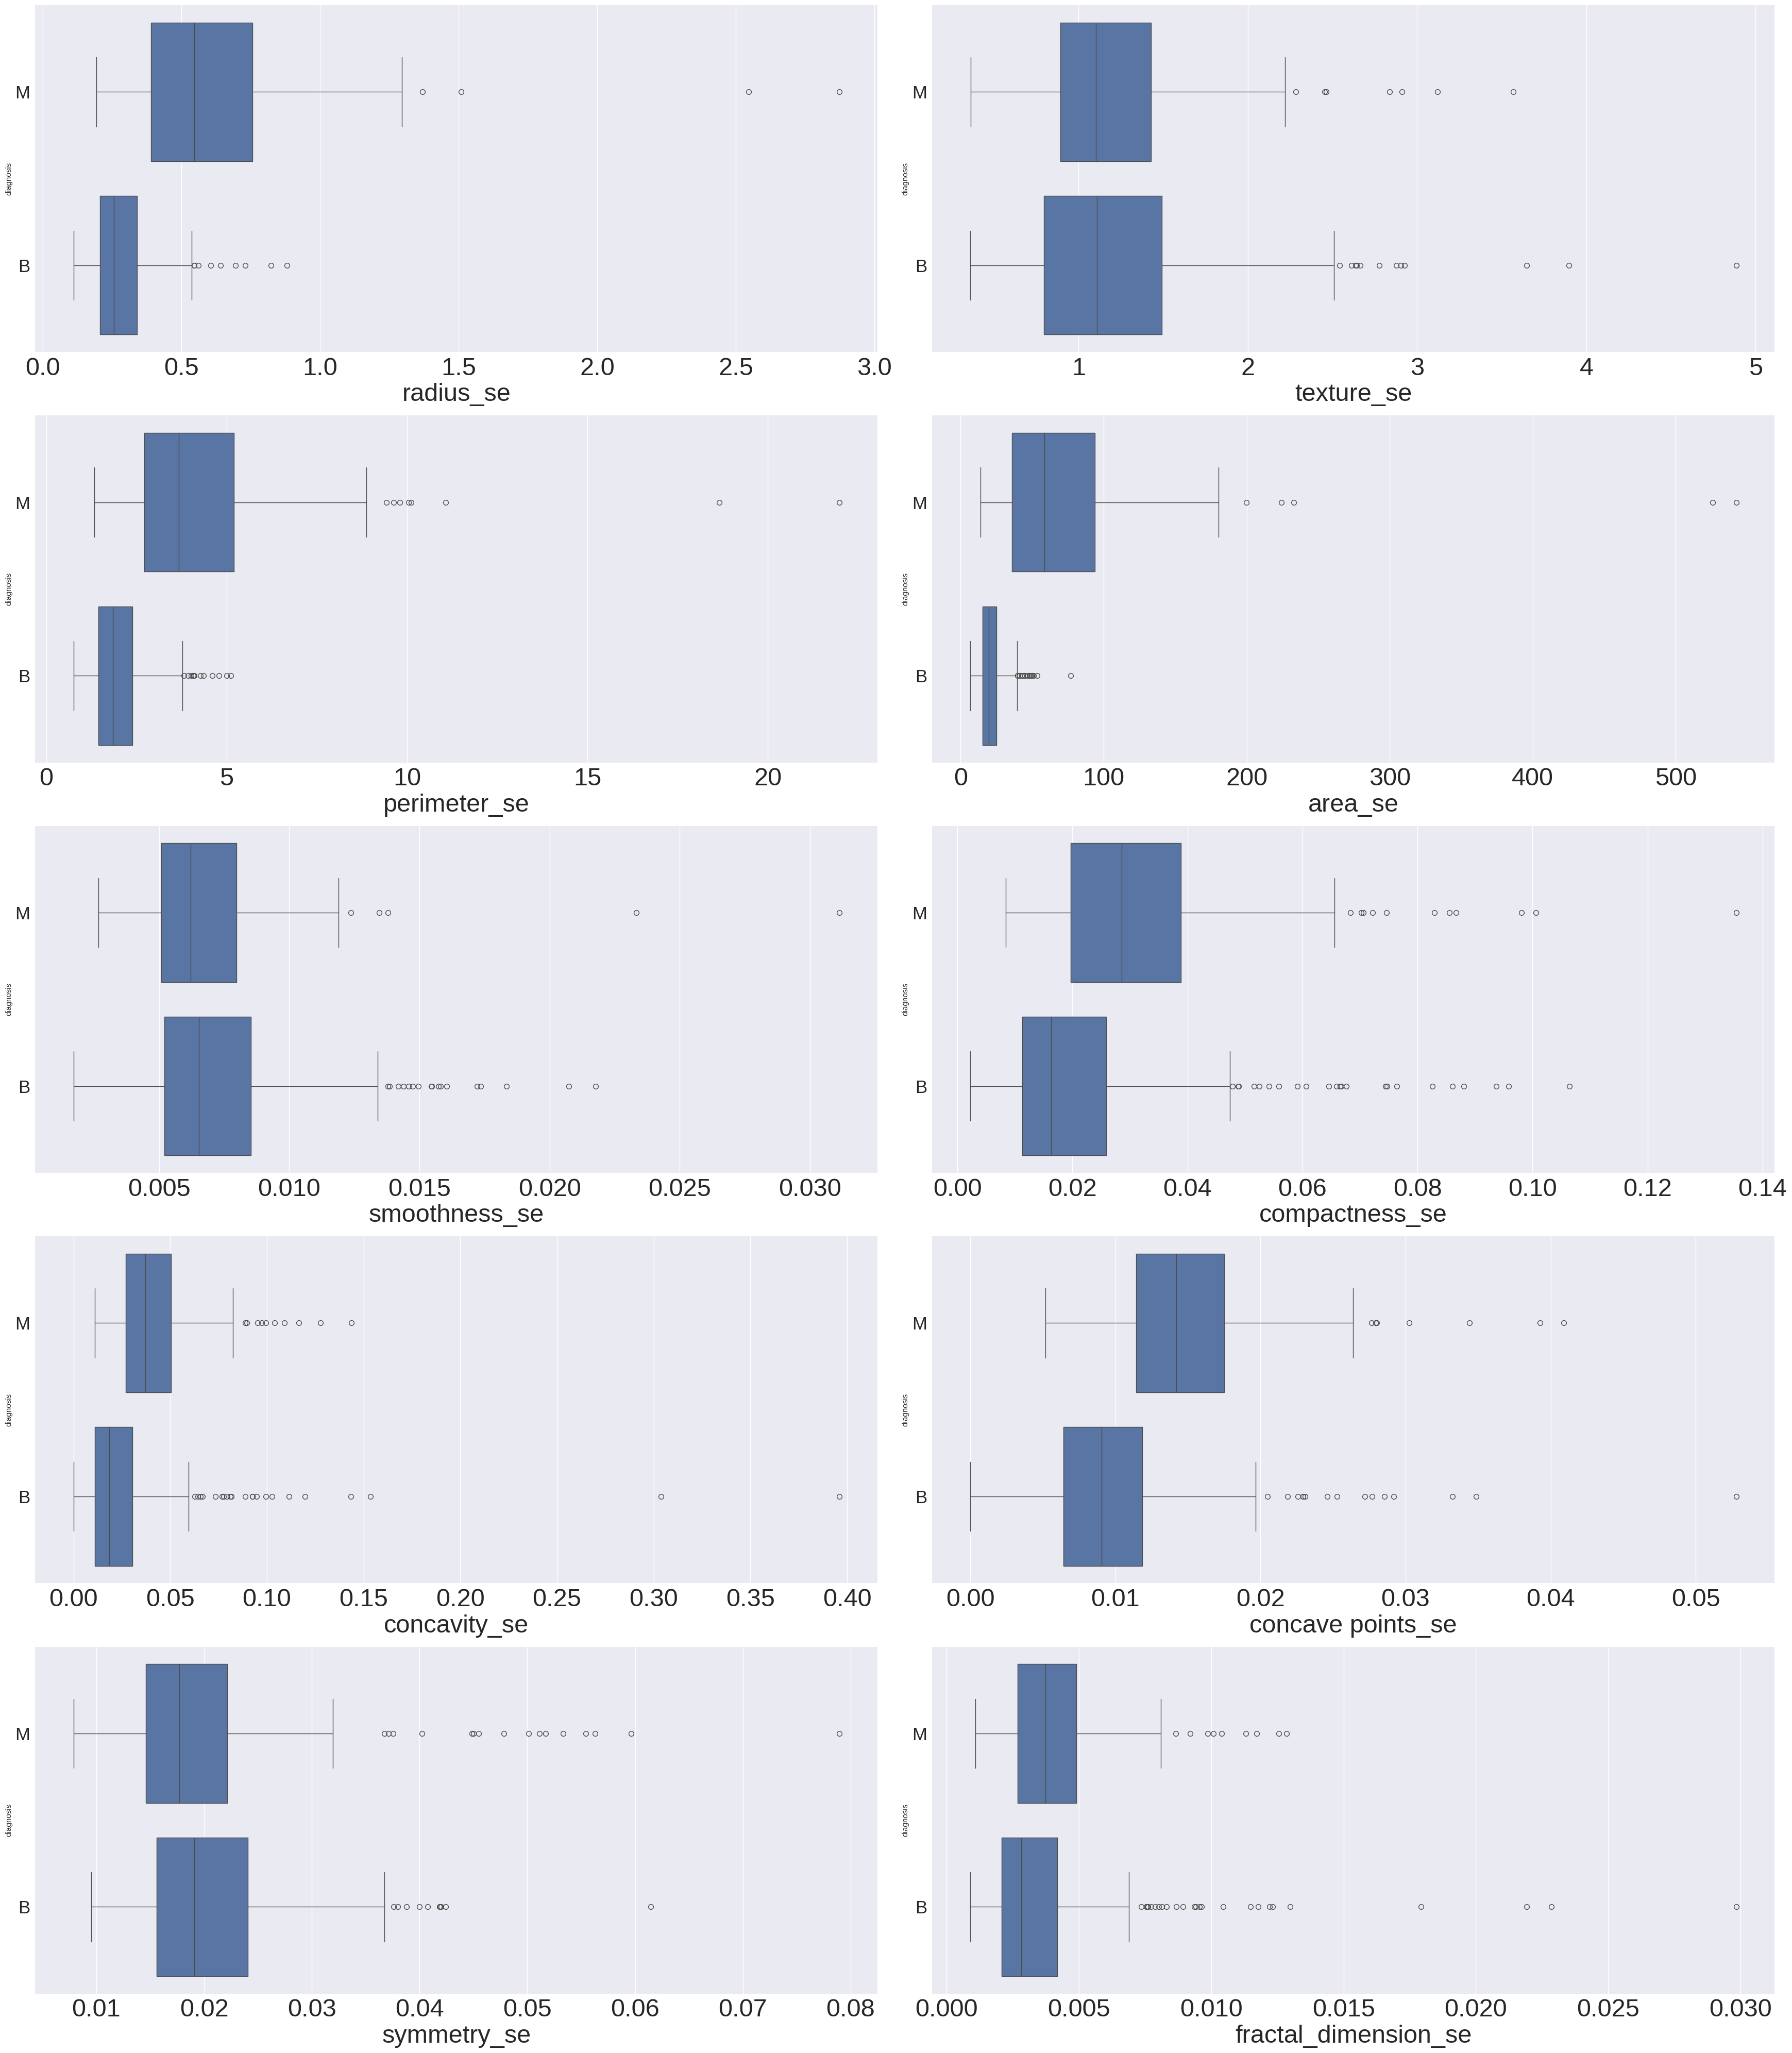

In [10]:
fig,axs = plt.subplots(ncols =2 ,nrows =5 ,figsize = (35,40),dpi= 100)
axs = axs.flatten()
for i,col in enumerate(df_viz2.drop(columns = 'diagnosis').columns) :
    sns.boxplot(x = col,y='diagnosis',data = df_viz2 , ax=axs[i])
    axs[i].set_xlabel(col,fontsize=35)
    axs[i].tick_params(axis= 'x',labelsize = 35)
    axs[i].tick_params(axis= 'y',labelsize = 25)

plt.tight_layout()
plt.show()

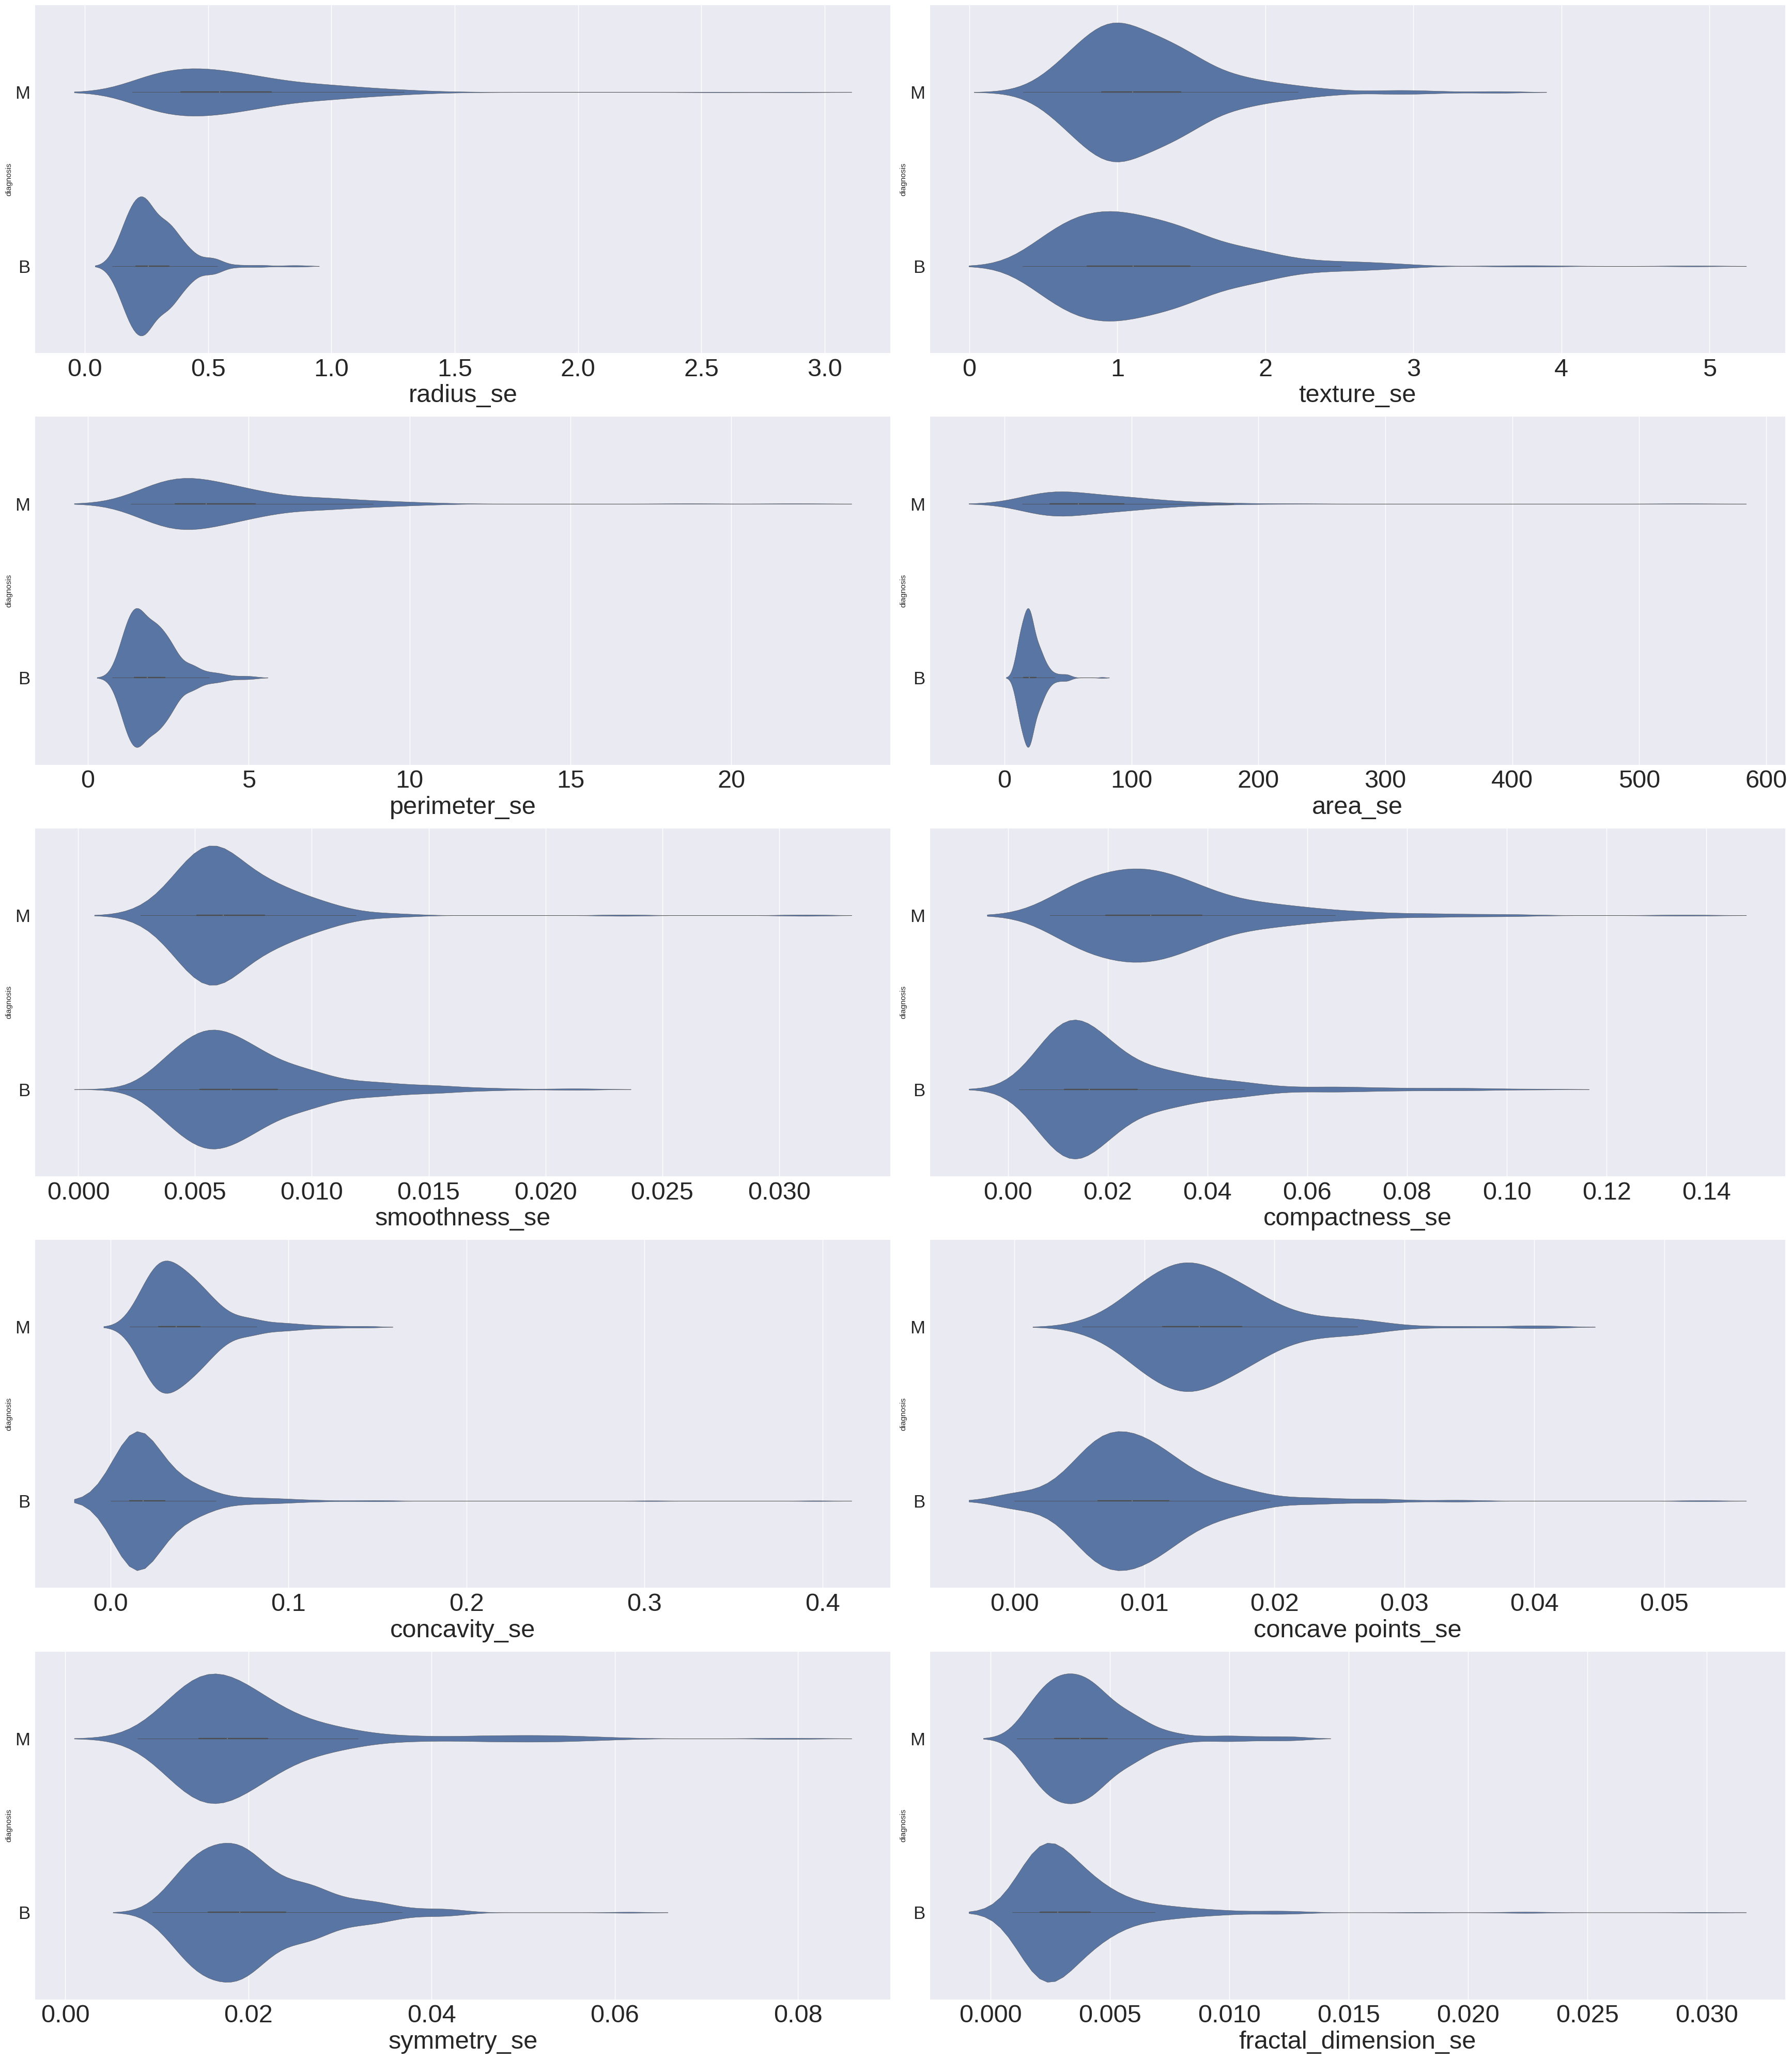

In [11]:
fig,axs = plt.subplots(ncols =2 ,nrows =5 ,figsize = (35,40),dpi= 100)
axs = axs.flatten()
for i,col in enumerate(df_viz2.drop(columns = 'diagnosis').columns) :
    sns.violinplot(x = col,y='diagnosis',data = df_viz2, ax=axs[i])
    axs[i].set_xlabel(col,fontsize=35)
    axs[i].tick_params(axis= 'x',labelsize = 35)
    axs[i].tick_params(axis= 'y',labelsize = 25)

plt.tight_layout()
plt.show()

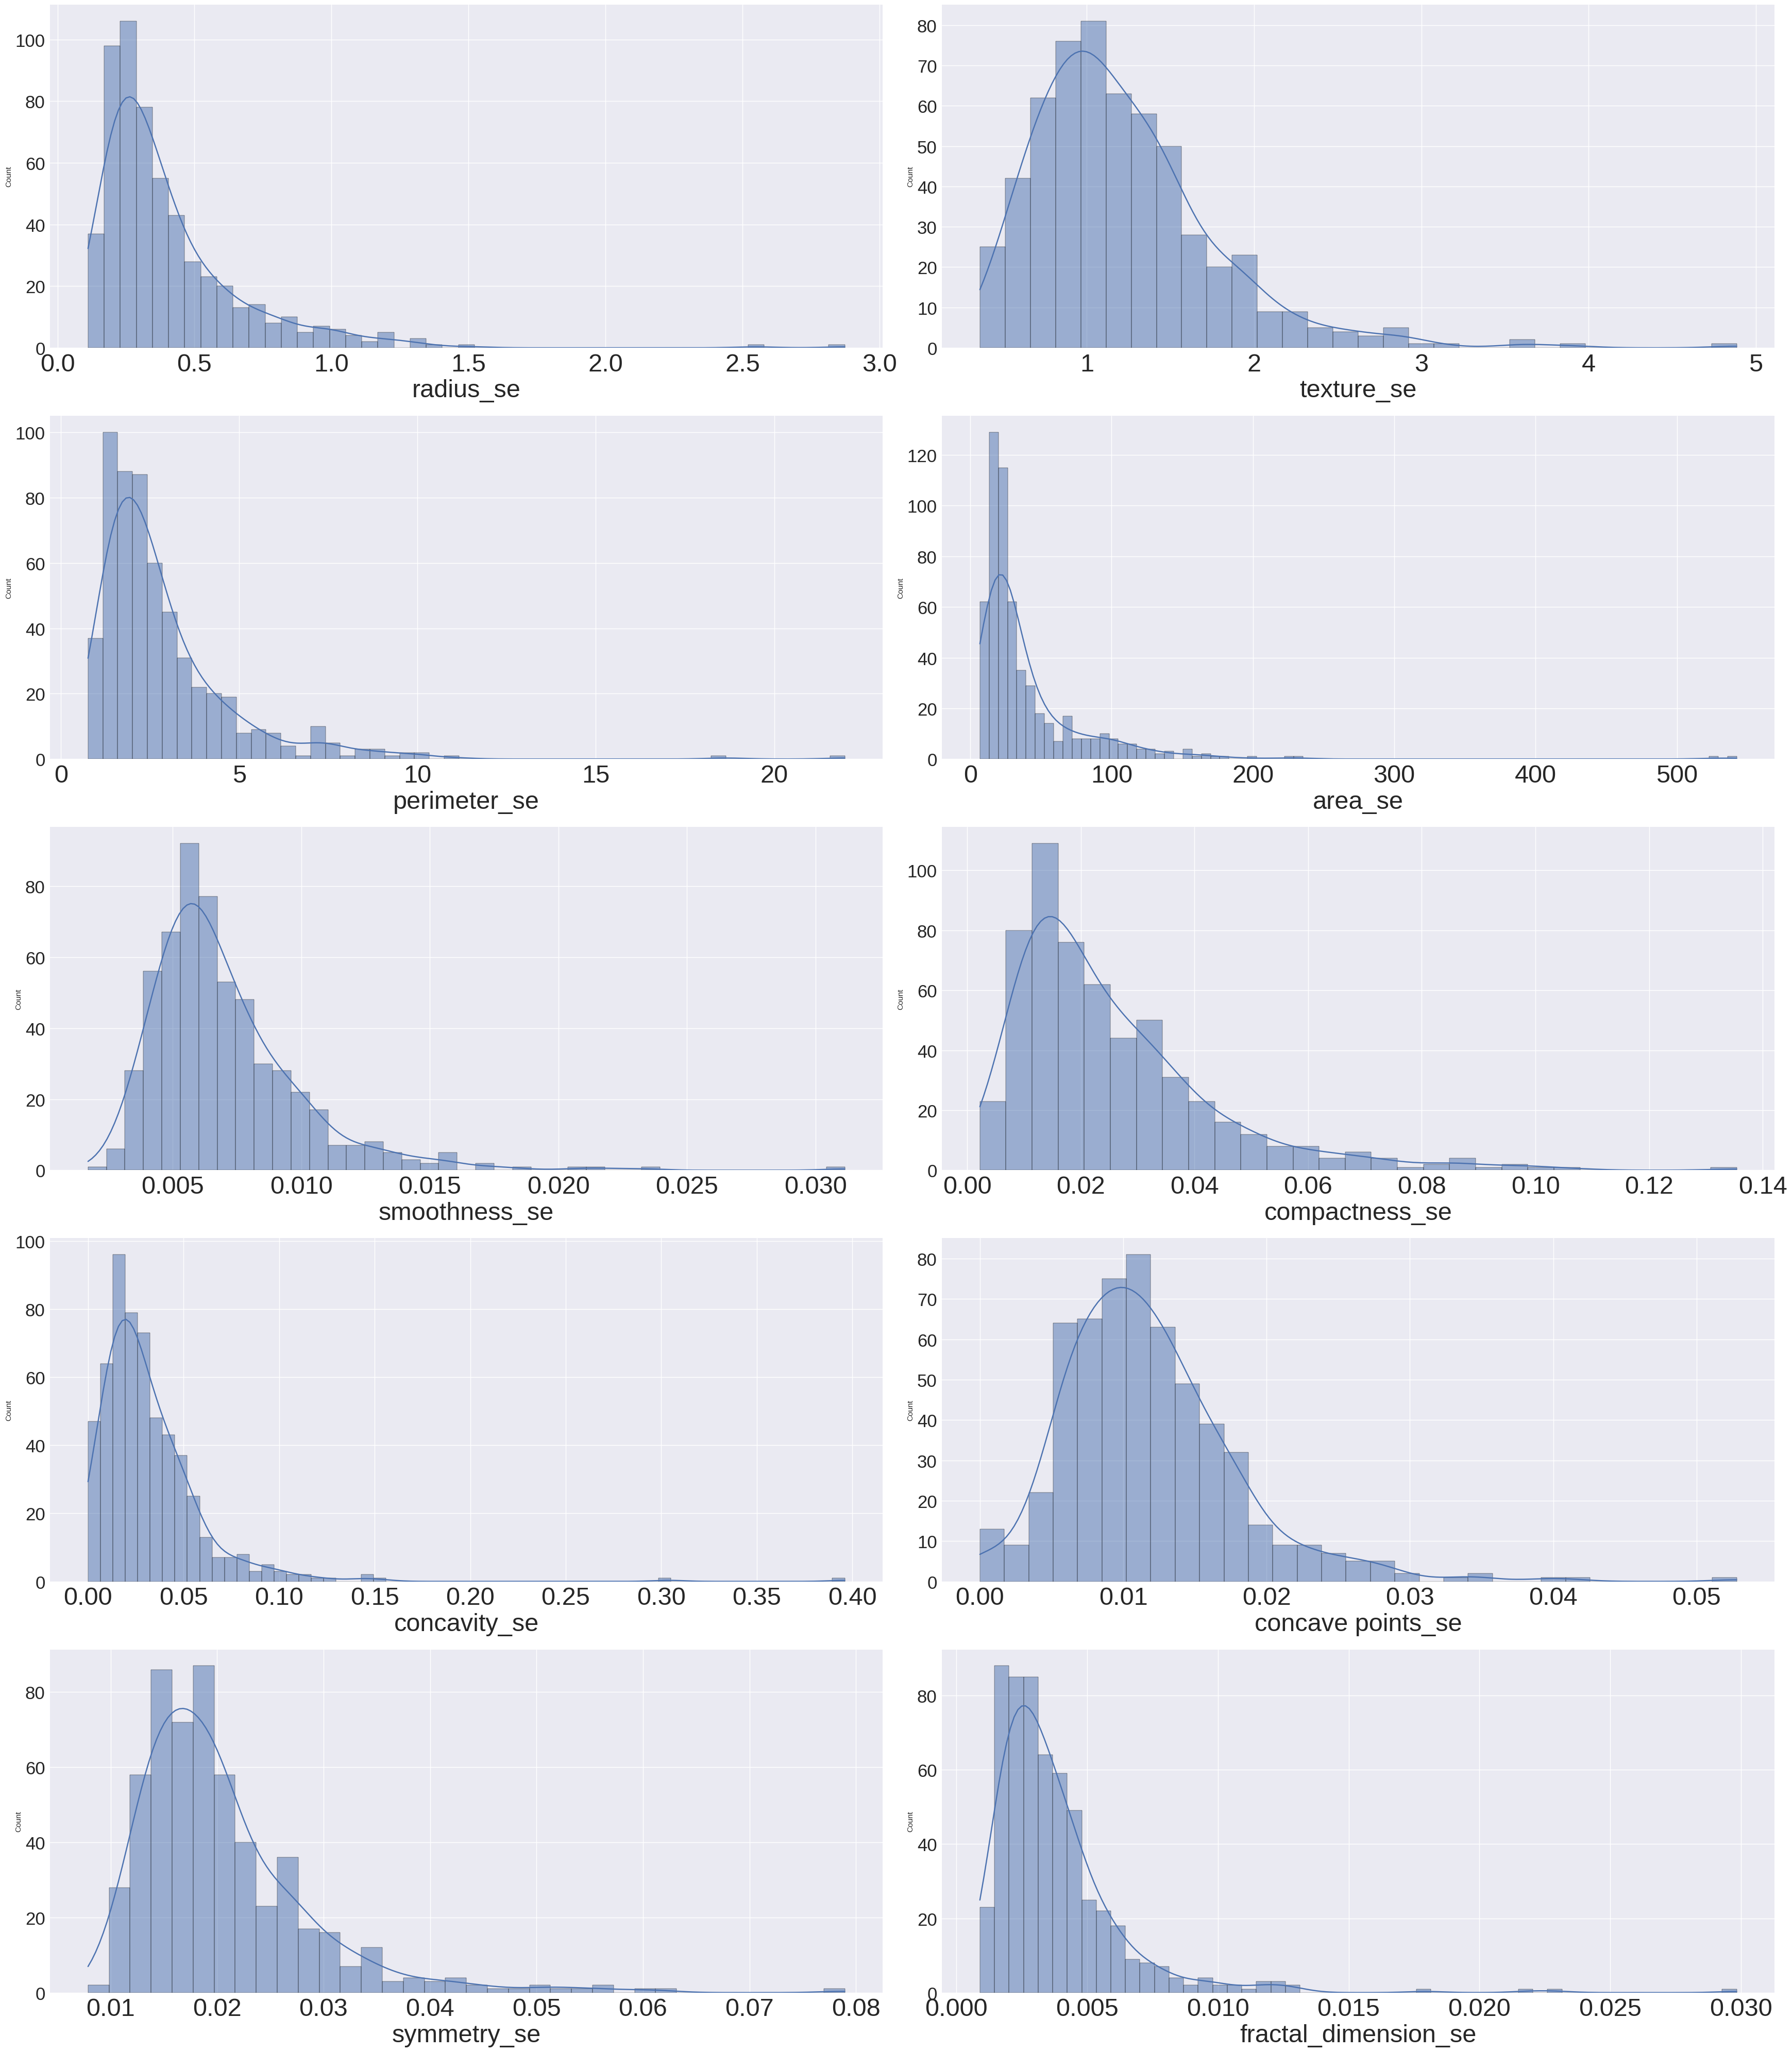

In [12]:
fig,axs = plt.subplots(ncols =2 ,nrows =5 ,figsize = (35,40),dpi= 100)
axs = axs.flatten()
for i,col in enumerate(df_viz2.drop(columns = 'diagnosis').columns) :
    sns.histplot(x = col,data = df_viz2,kde=True, ax=axs[i])
    axs[i].set_xlabel(col,fontsize=35)
    axs[i].tick_params(axis= 'x',labelsize = 35)
    axs[i].tick_params(axis= 'y',labelsize = 25)

plt.tight_layout()
plt.show()

# Analyis on the third part

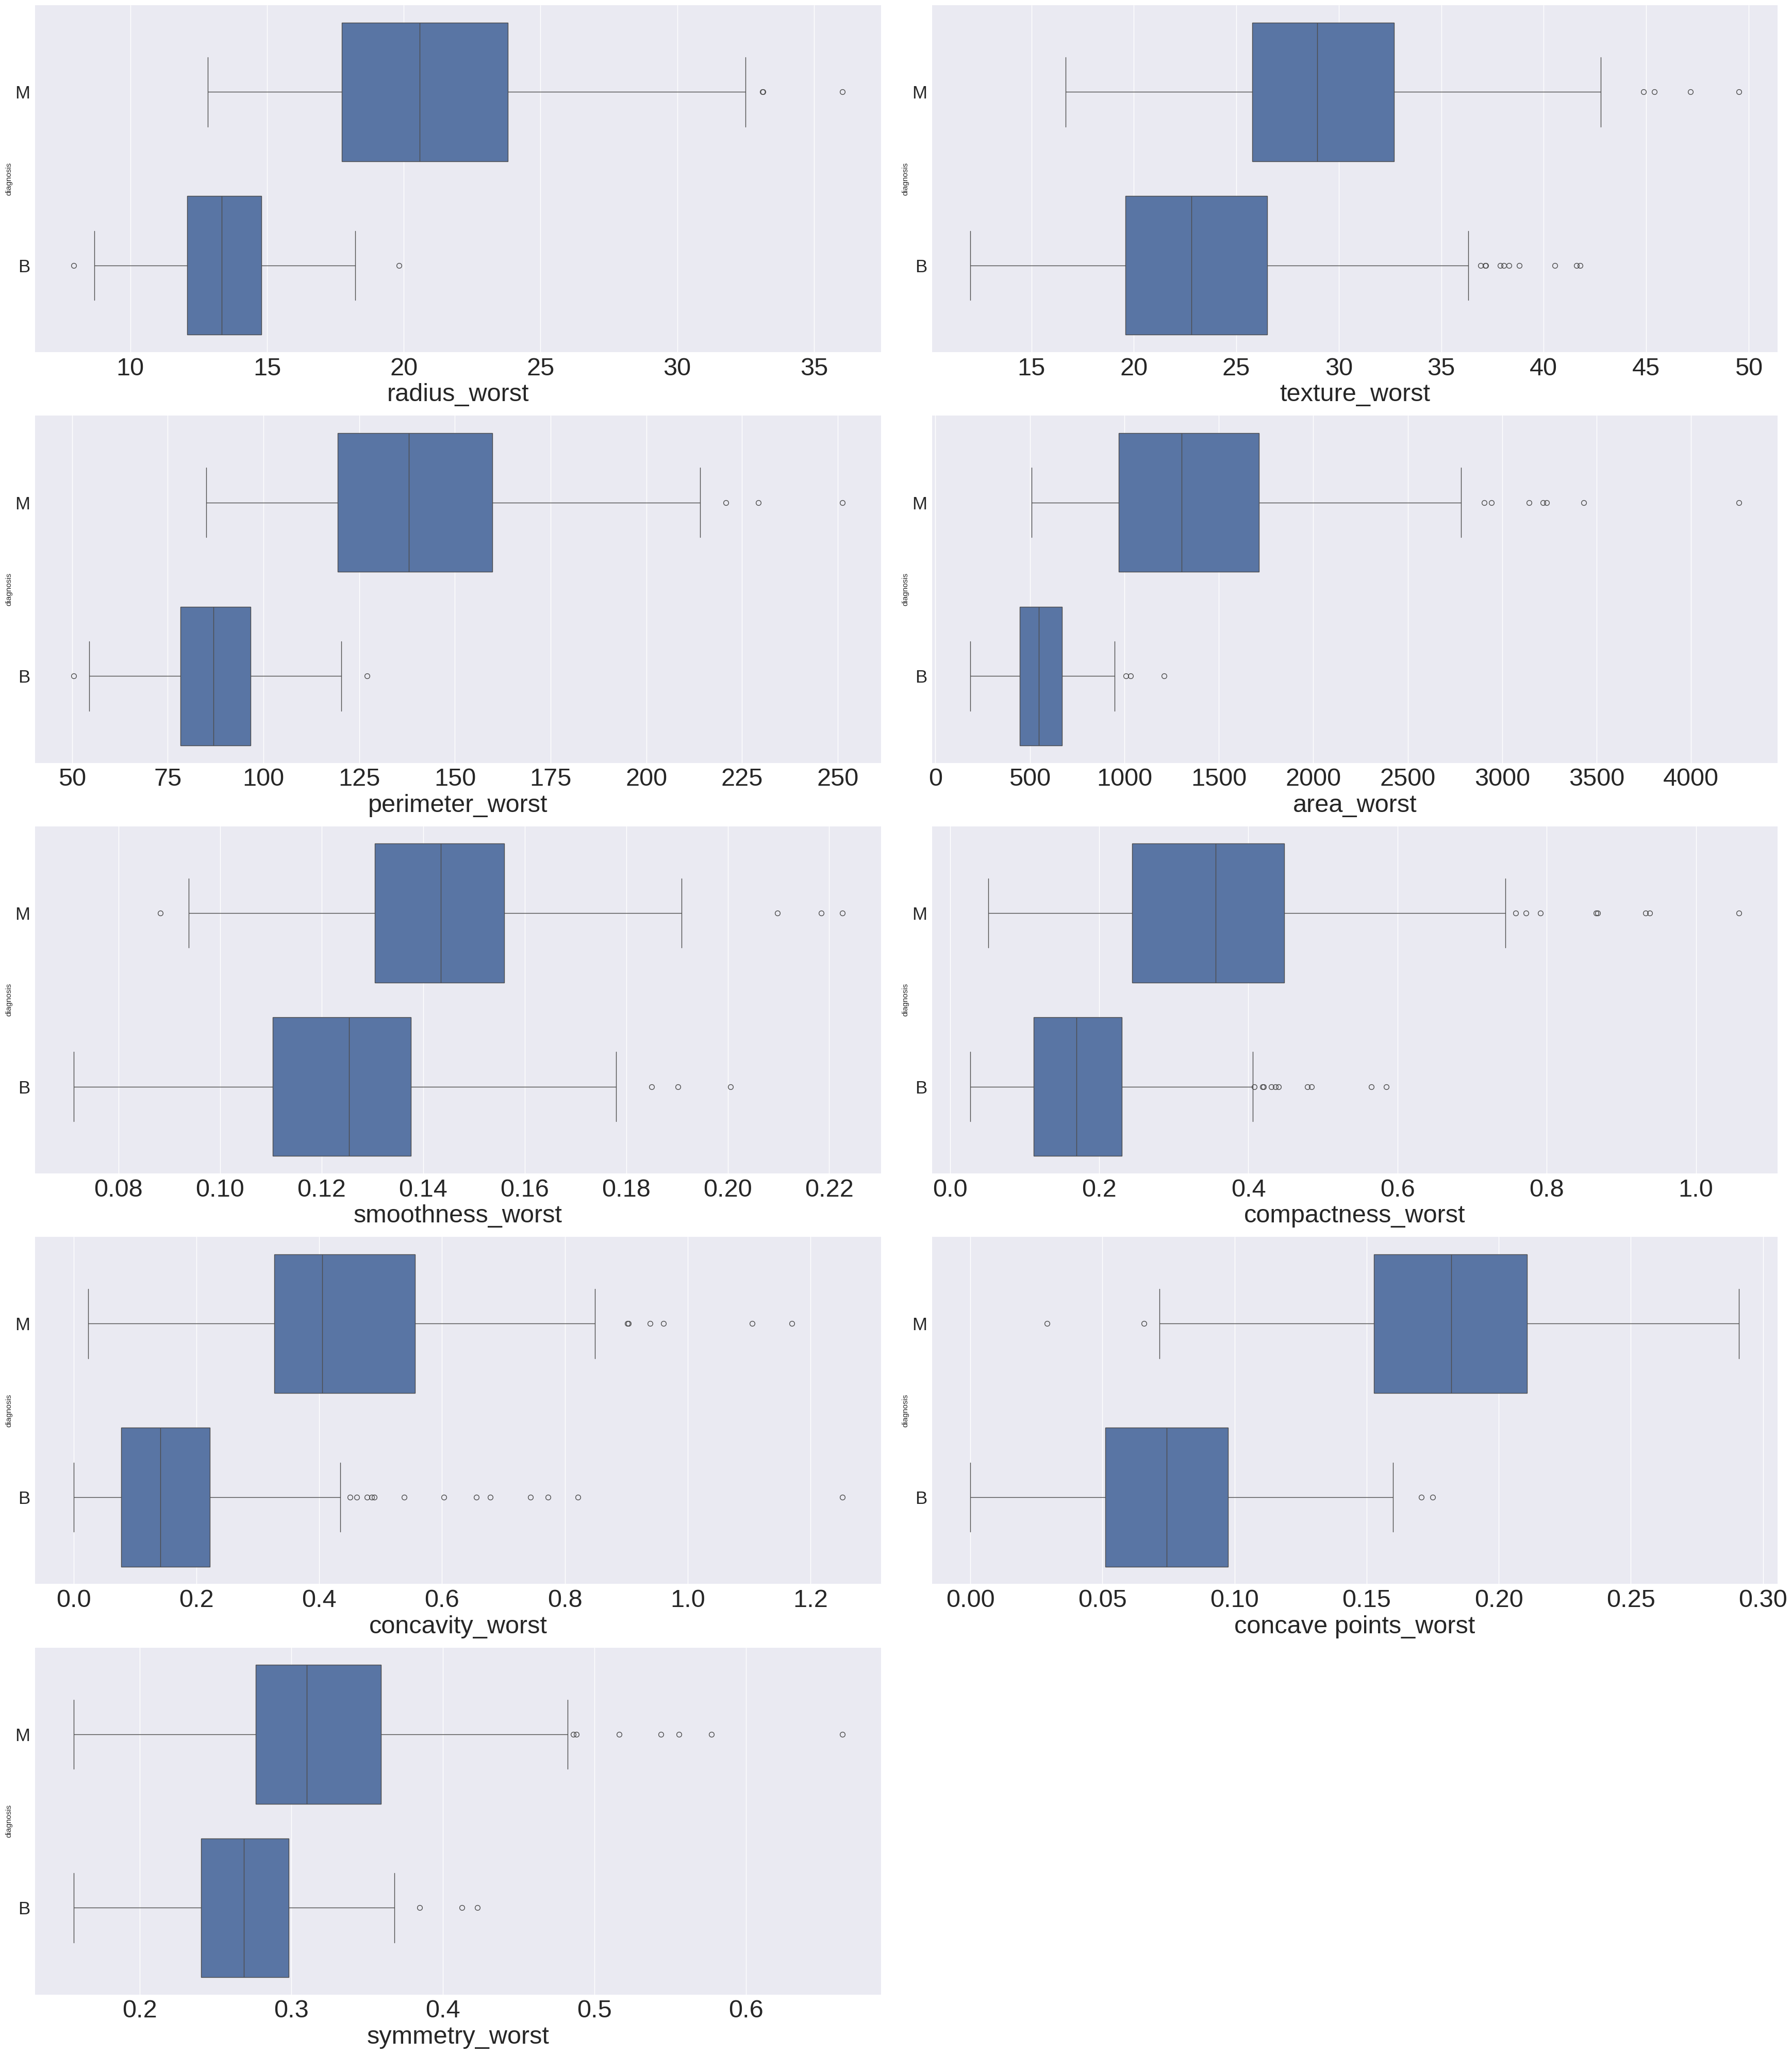

In [13]:
fig,axs = plt.subplots(ncols =2 ,nrows =5 ,figsize = (35,40),dpi= 100)
axs = axs.flatten()
for i,col in enumerate(df_viz3.drop(columns = 'diagnosis').columns) :
    sns.boxplot(x = col,y='diagnosis',data = df_viz3, ax=axs[i])
    axs[i].set_xlabel(col,fontsize=35)
    axs[i].tick_params(axis= 'x',labelsize = 35)
    axs[i].tick_params(axis= 'y',labelsize = 25)

axs[-1].set_visible(False)
plt.tight_layout()
plt.show()

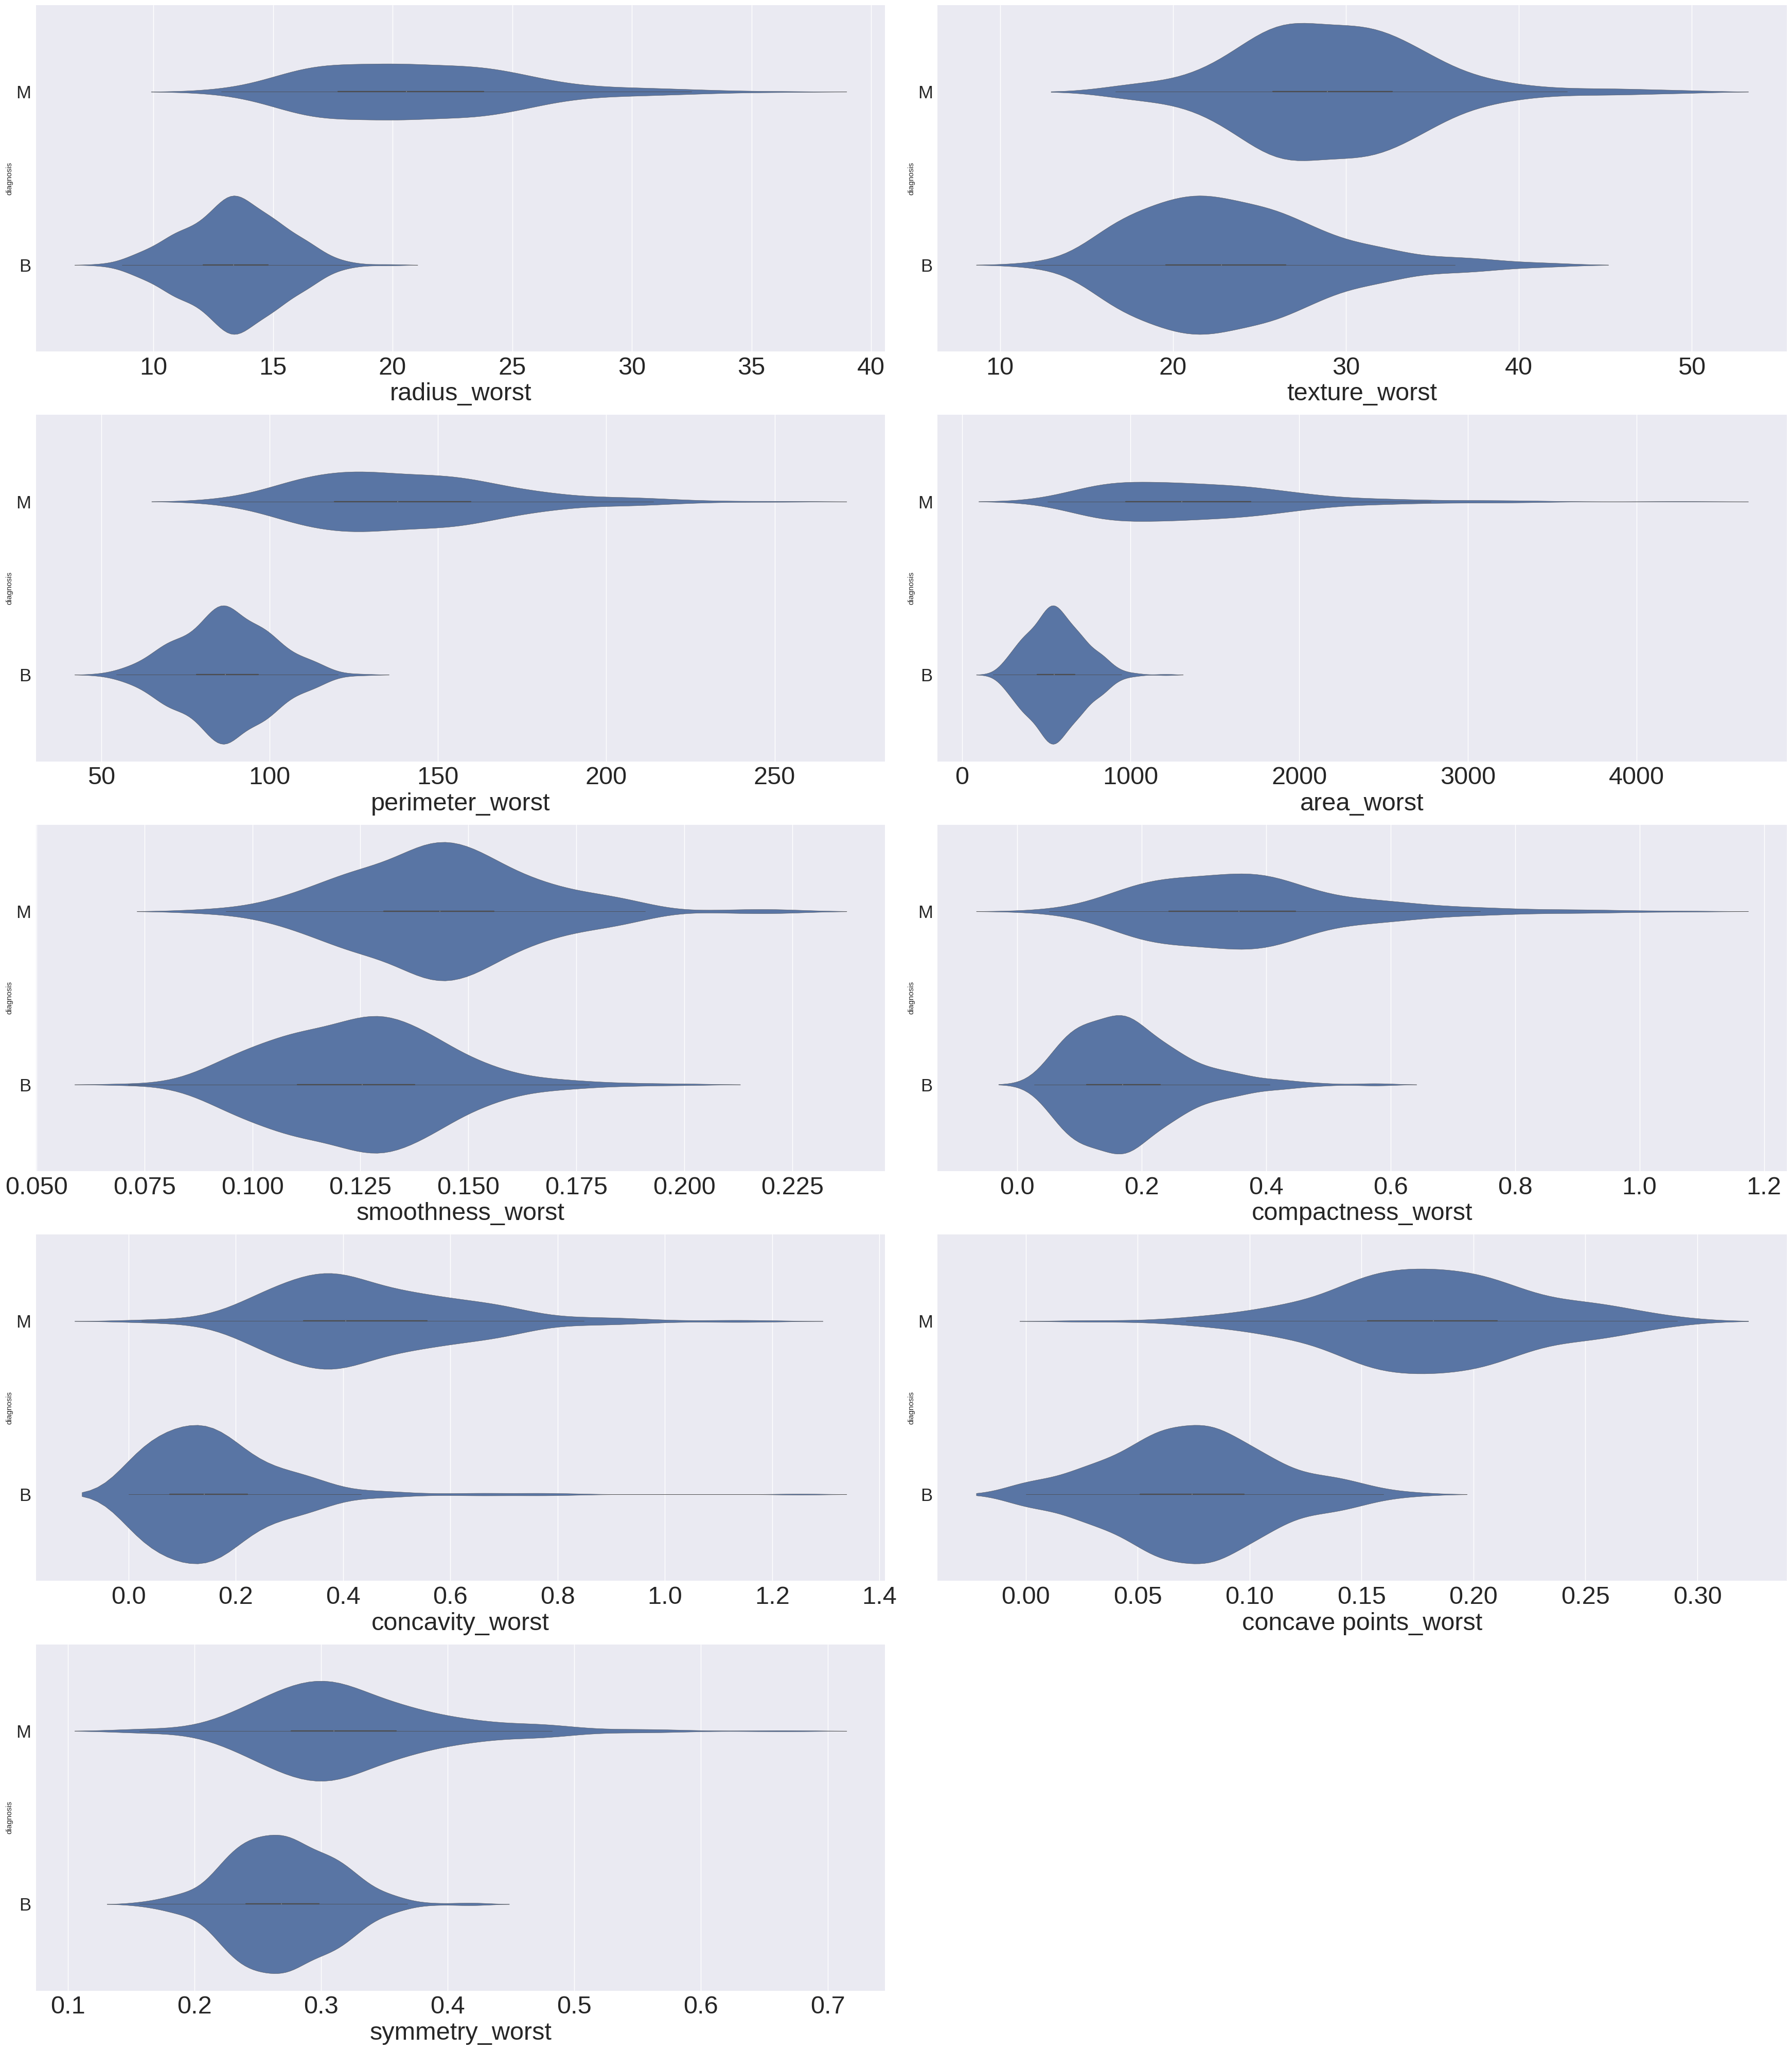

In [14]:
fig,axs = plt.subplots(ncols =2 ,nrows =5 ,figsize = (35,40),dpi= 100)
axs = axs.flatten()
for i,col in enumerate(df_viz3.drop(columns = 'diagnosis').columns) :
    sns.violinplot(x = col,y='diagnosis',data = df_viz3, ax=axs[i])
    axs[i].set_xlabel(col,fontsize=35)
    axs[i].tick_params(axis= 'x',labelsize = 35)
    axs[i].tick_params(axis= 'y',labelsize = 25)

axs[-1].set_visible(False)
plt.tight_layout()
plt.show()

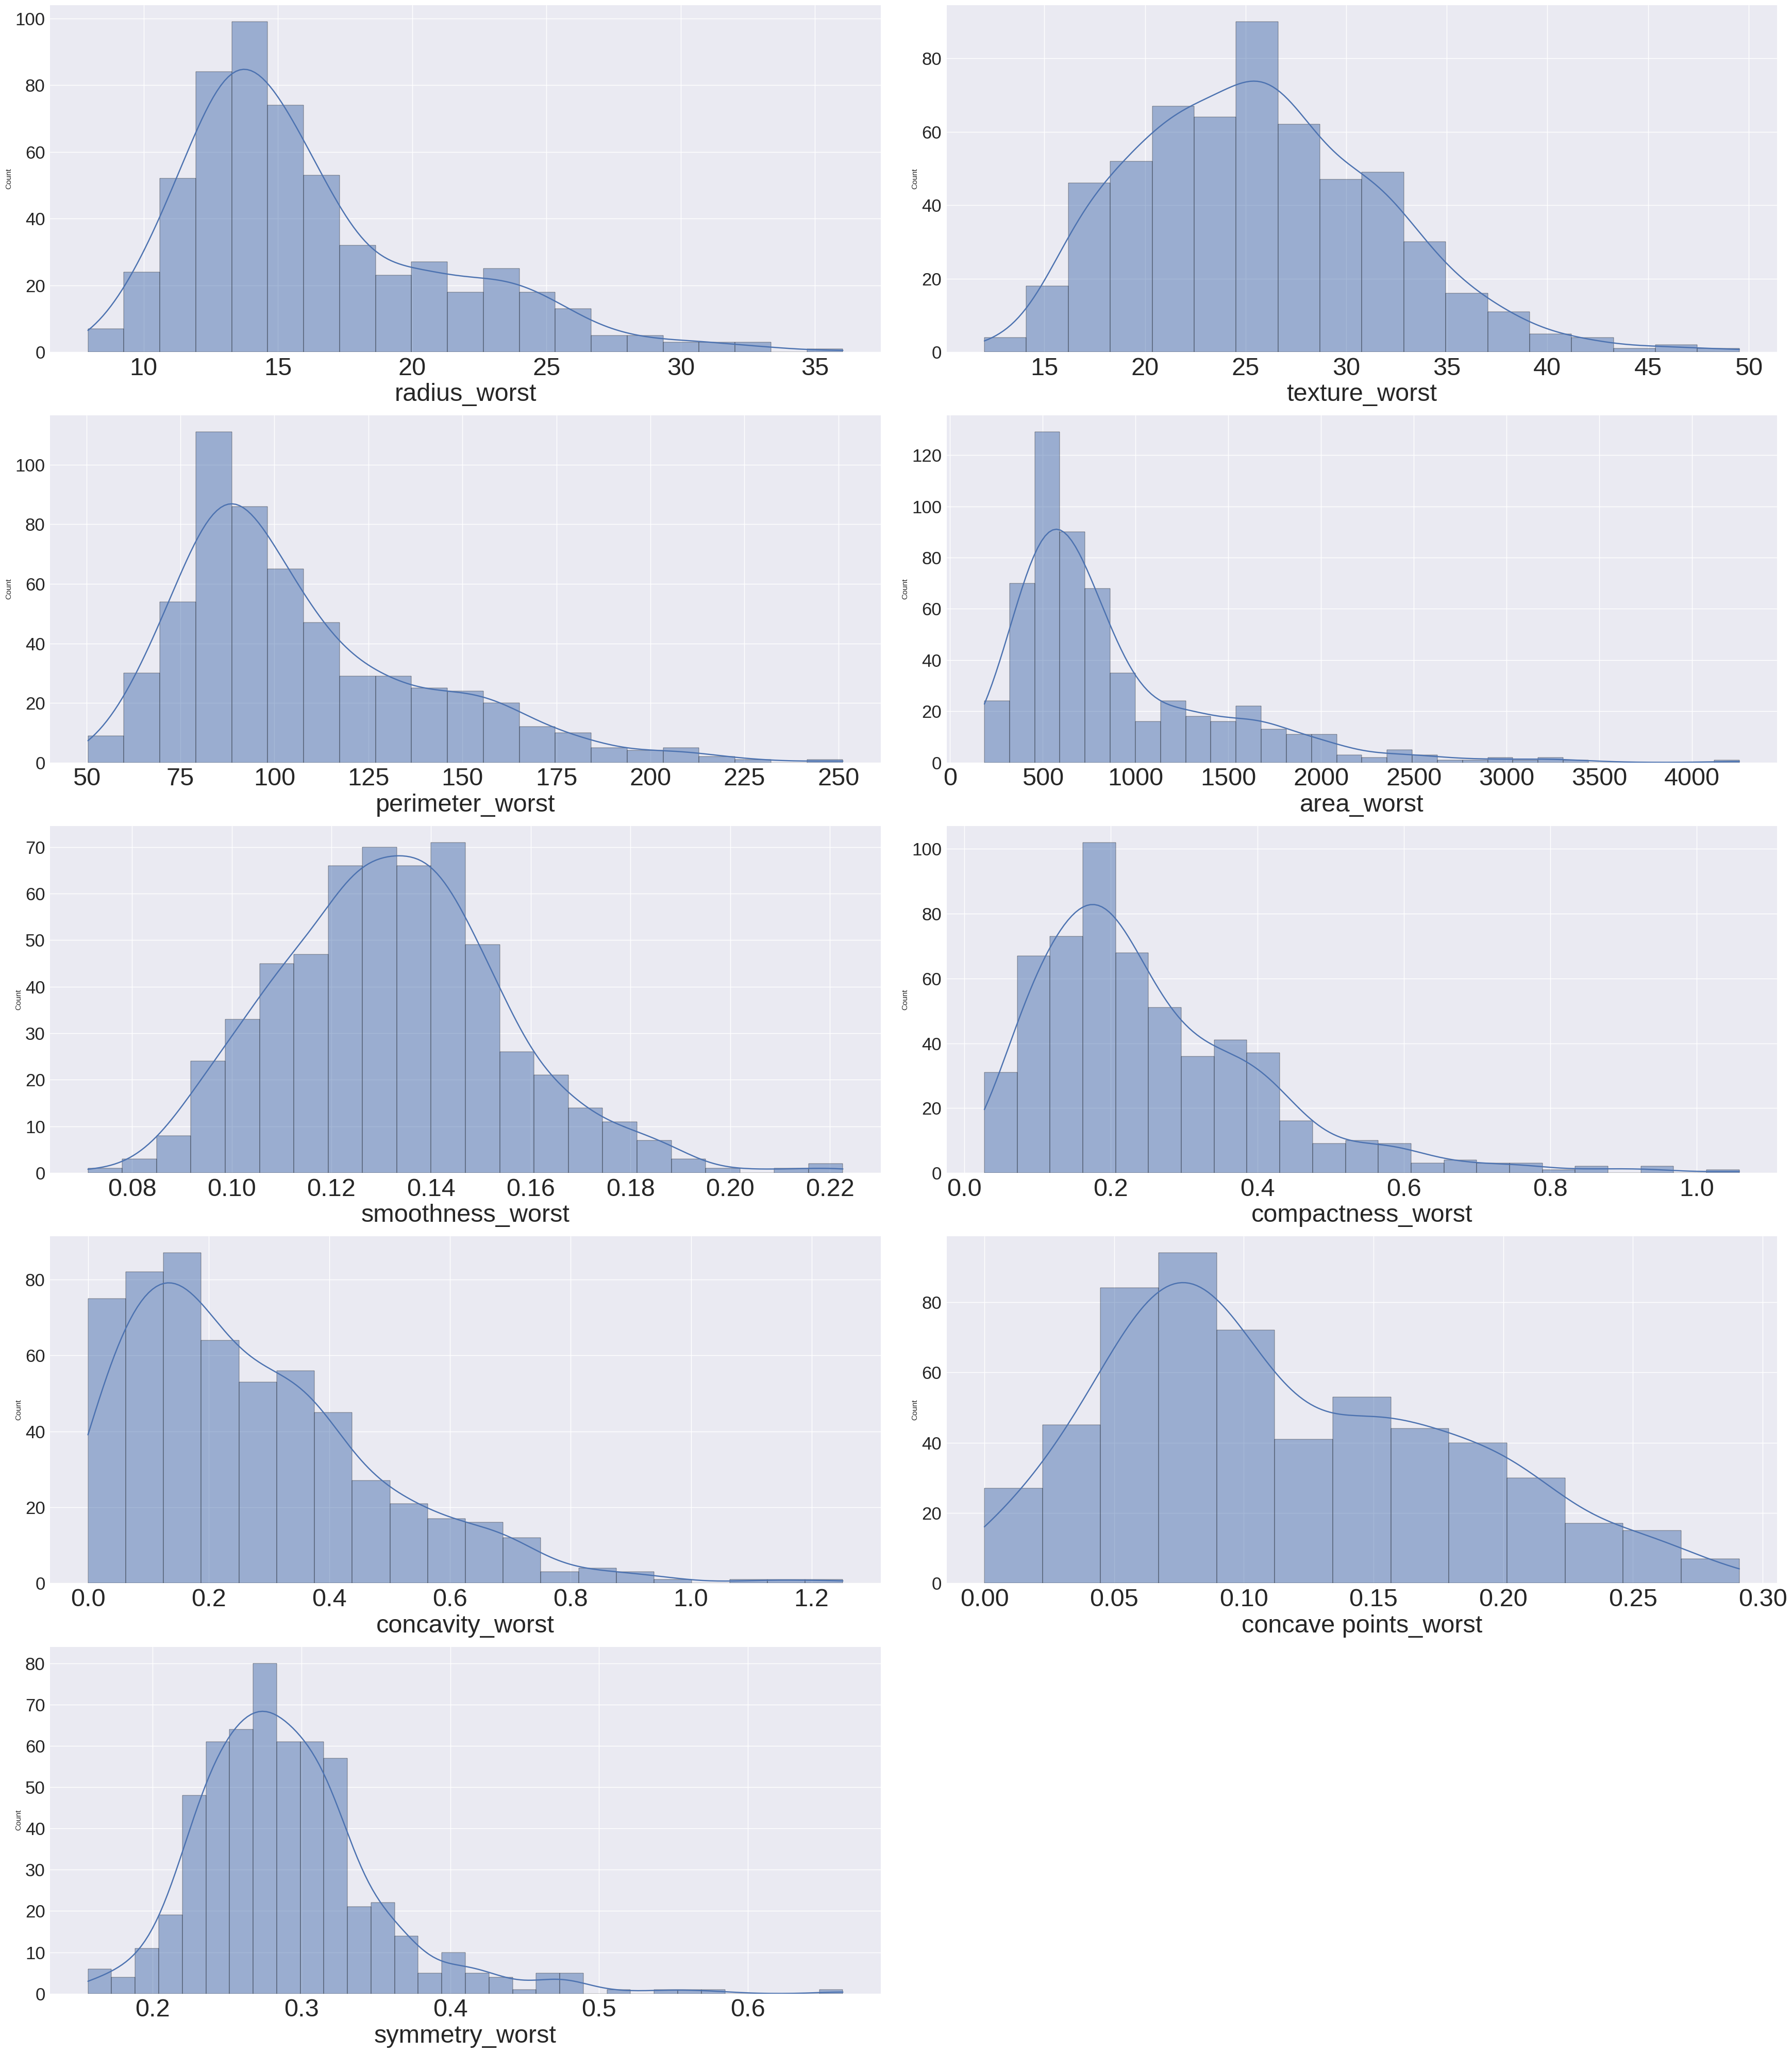

In [15]:
fig,axs = plt.subplots(ncols =2 ,nrows =5 ,figsize = (35,40),dpi= 100)
axs = axs.flatten()
for i,col in enumerate(df_viz3.drop(columns = 'diagnosis').columns) :
    sns.histplot(x = col,data = df_viz3,kde=True, ax=axs[i])
    axs[i].set_xlabel(col,fontsize=35)
    axs[i].tick_params(axis= 'x',labelsize = 35)
    axs[i].tick_params(axis= 'y',labelsize = 25)

axs[-1].set_visible(False)
plt.tight_layout()
plt.show()

# Correlation Analysis

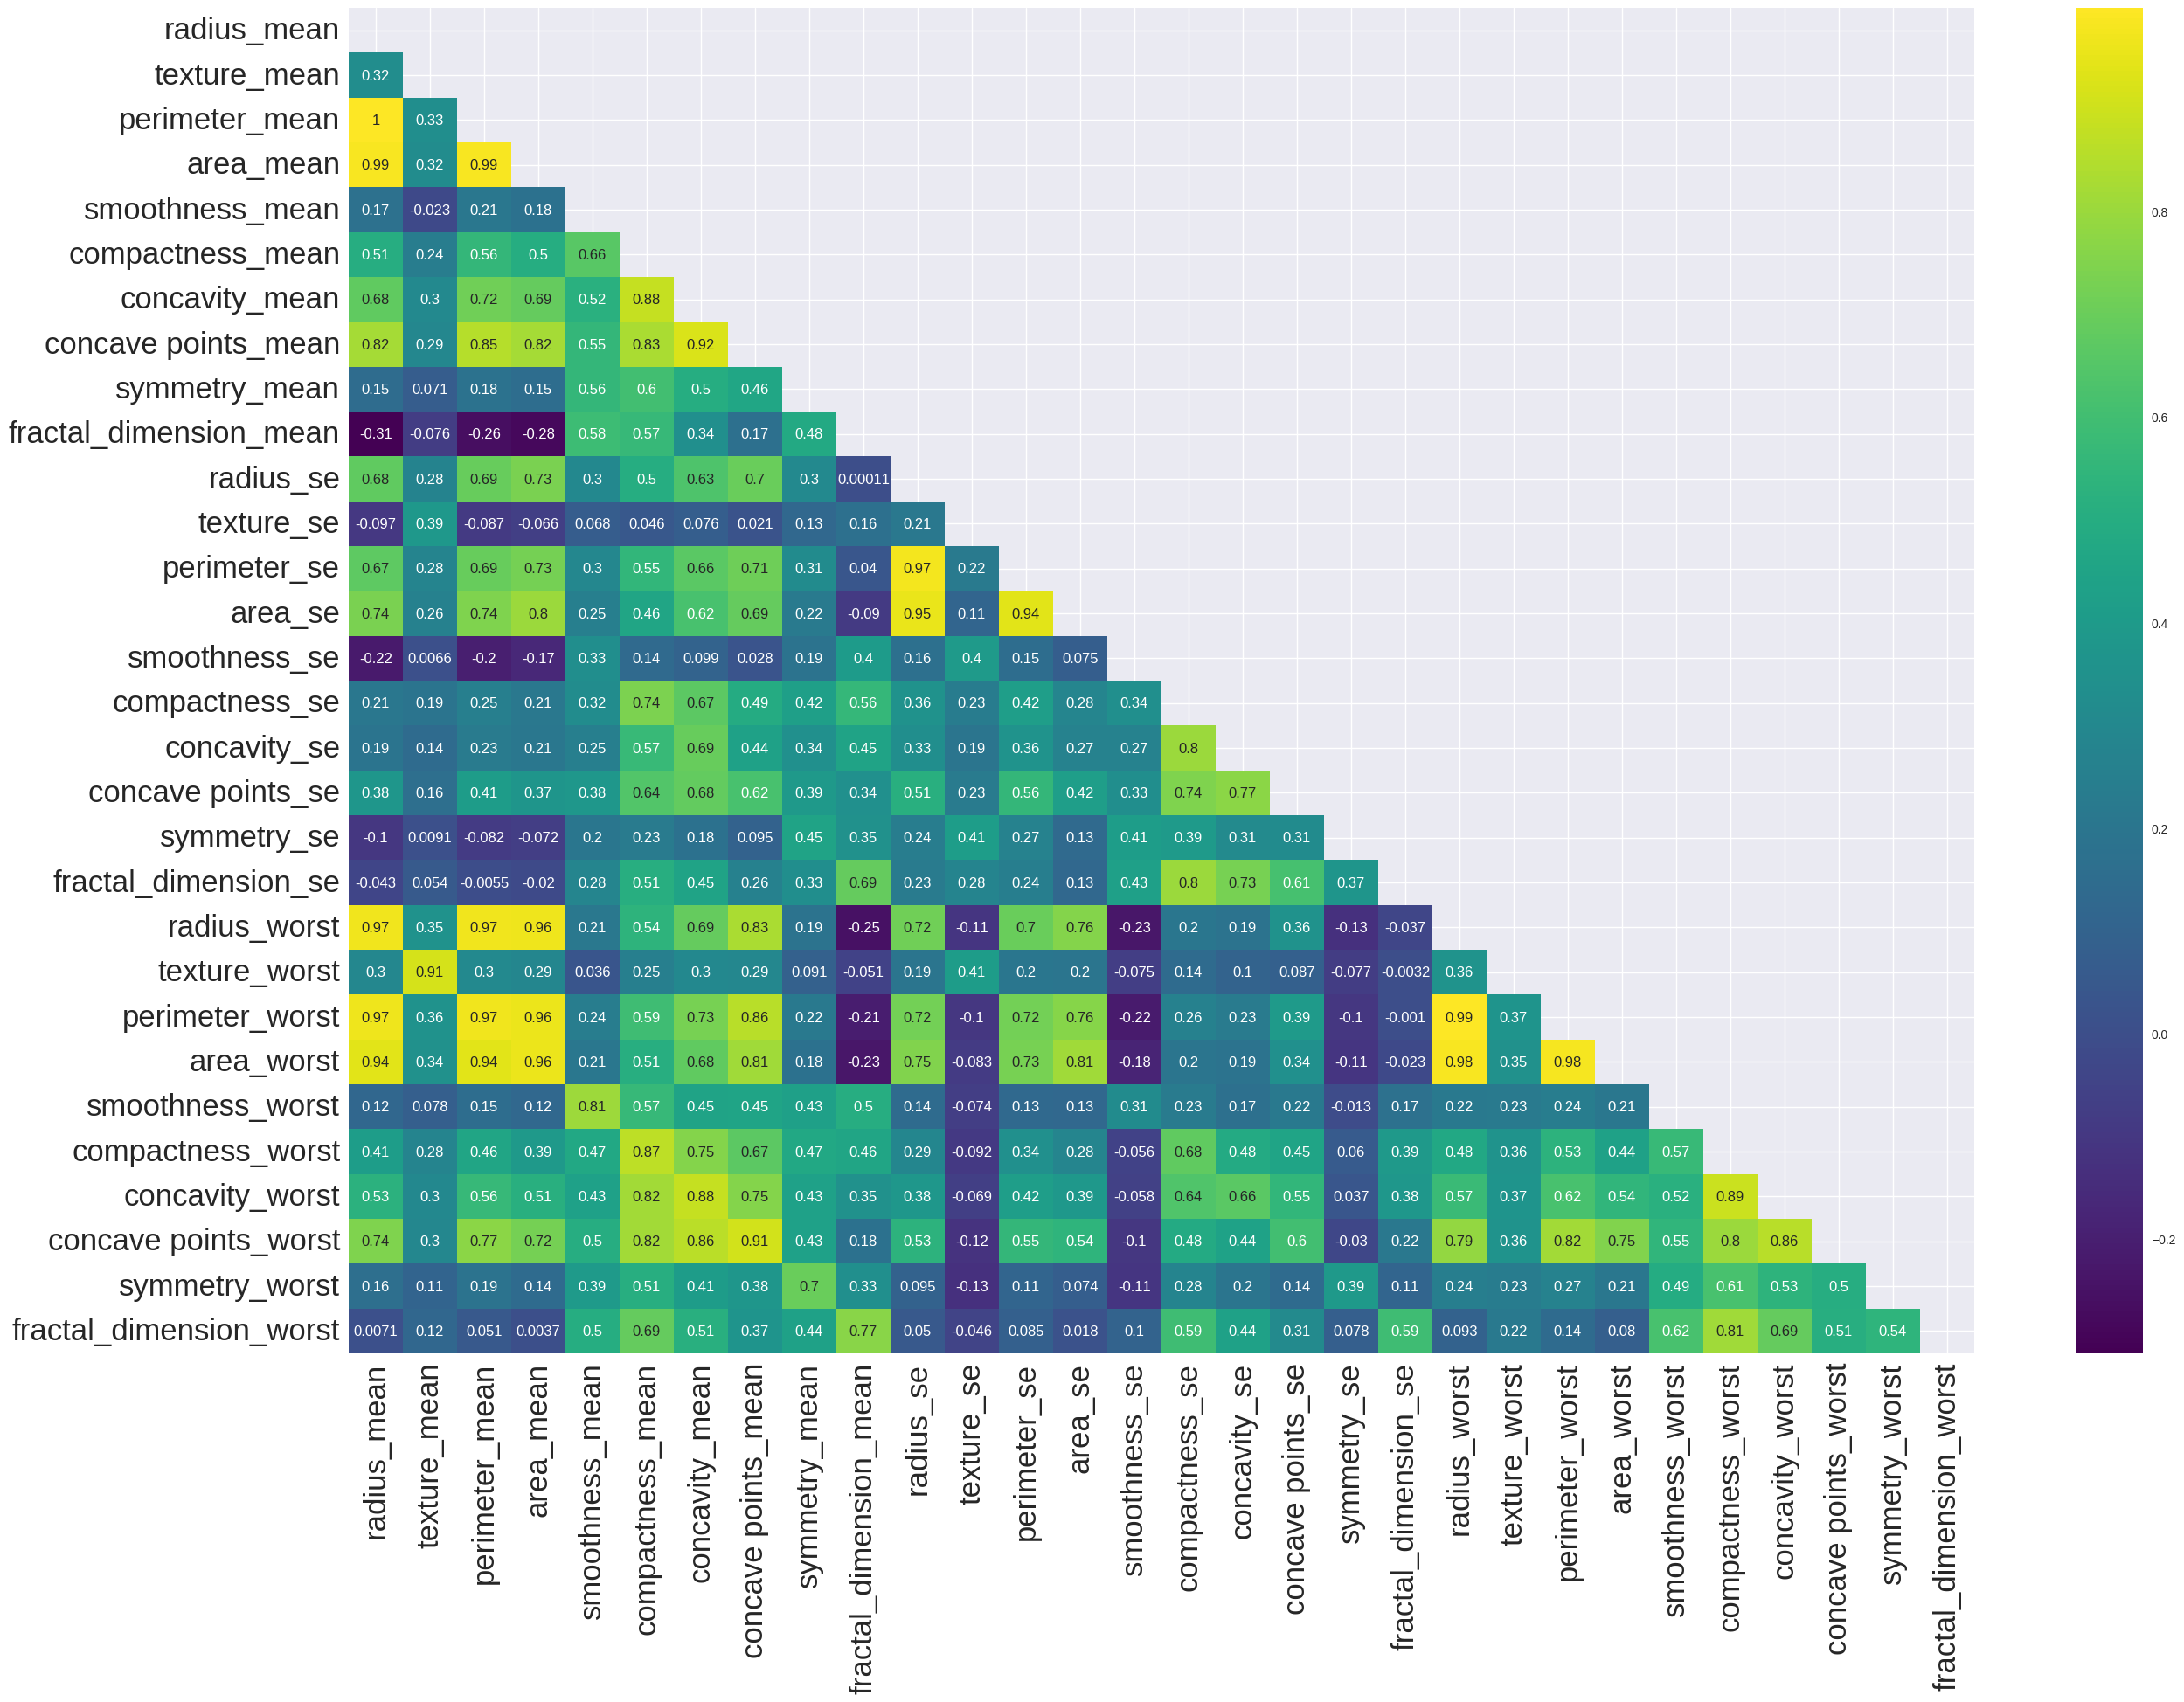

In [16]:
# ----- Fail code -----
# plt.figure(figsize=(30,20))
# sns.heatmap(df.corr(),cmap='viridis',annot=True,mask = np.tril(np.ones_like(df.corr(), dtype=bool)))
# plt.xticks(fontsize=25,rotation=90)
# plt.yticks(fontsize=25,rotation=0)
# plt.show()

numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()

plt.figure(figsize=(30, 20))

# Show only the lower triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    cmap="viridis",
    annot=True,
    mask=mask
)

plt.xticks(fontsize=25, rotation=90)
plt.yticks(fontsize=25, rotation=0)
plt.show()

# Categotical Target analysis

,count
diagnosis,
B,357
M,212


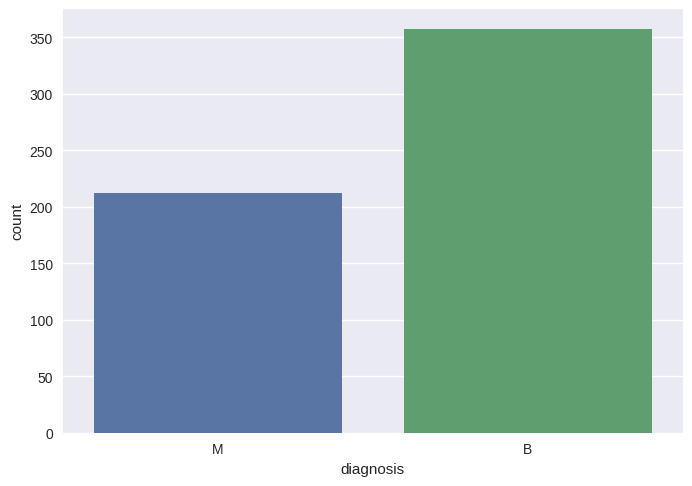

In [17]:
sns.countplot(x='diagnosis',hue='diagnosis',data = df)
df['diagnosis'].value_counts()

# Analysis Explanation before getting to Making Models
**Based on the analysis above we can see that :**

> The data is allready preprocessed

> all the features are continous but the target is discrete(so we can use classificaion algorithms and for naive bayes we can use gaussian)

>all the distributions are normal

> there are no null values that explains the data being preprocessed before

> there are many features but the data samples are low so it gets harder to work on

> the target is unbalanced but we can see that the higher the values the more the chance of cancer type being "MALIGNANT"

> the correlation between most features is high

****So I decide not to change anything in the data and go on making models with the unchanged dataset****

# Normalizing Data
> Malignant  =  1

> Benign  =  0

In [18]:
# --- Fail Code ---
df['diagnosis'] = df['diagnosis'].replace({'M' : 1 , 'B' : 0})
scaler = preprocessing.StandardScaler()
X = df.drop(columns = 'diagnosis').values
X = scaler.fit_transform(X)
Y = df['diagnosis'].values.reshape(-1,1)
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)


# Roc , Auc and f1 score comparison


> **I do this to realize which models to better with their default values so I can decide with model to use**

In [19]:
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.ensemble import AdaBoostClassifier

In [20]:
models = [LogisticRegression(random_state=42),KNeighborsClassifier(),
          SVC(probability=True, random_state=42),GaussianNB(),
          DecisionTreeClassifier(random_state=42),RandomForestClassifier(random_state=42),xgb.XGBClassifier(),AdaBoostClassifier()]
model_names = ['LogisticRegression','KNN','SVM','NaiveBayes','DecisionTree','RandomForest','XGBoost','AdaBoostClassifier']
auc_scores = []


# 手寫 SVM：用內點法 (Interior Point Method) 求解對偶問題

以下依照課堂教授的 Primal-Dual Interior Point Method，將 soft-margin kernel SVM 的對偶問題自行推導並求解，取代（同時保留作為對照）原本 `sklearn.svm.SVC` 使用的 LIBSVM 求解器。下方 `IPMSVM` 類別即是此推導的程式實作。

## 1. 對偶問題 (Dual Problem)

Soft-margin SVM 的對偶問題為：

$$ \max_{\alpha} \sum_{i=1}^m \alpha_i - \frac{1}{2}\sum_{i=1}^m\sum_{j=1}^m \alpha_i\alpha_j y_i y_j K(x_i,x_j) $$

限制條件：

$$ \sum_{i=1}^m \alpha_i y_i = 0, \quad 0 \le \alpha_i \le C $$

其中 $K(x_i,x_j)$ 為 Kernel 函數（Linear / RBF / Polynomial / Sigmoid，對應 `_kernel_matrix` 的四個分支），$m$ 為訓練樣本數。

## 2. 化為標準二次規劃 (QP) 形式

引入鬆弛變數 $\theta_i \ge 0$，使得 $\alpha_i + \theta_i = C$（即程式中的 `theta = C - alpha`），把上界限制 $\alpha_i \le C$ 轉換成等式限制，可將對偶問題改寫為：

$$ \max_{\Lambda \ge 0} \ -\frac{1}{2}\Lambda^T \bar{Q}\Lambda + q^T\Lambda \quad \text{s.t.} \quad A\Lambda = b $$

其中：

- $\Lambda = \begin{bmatrix}\alpha \\ \theta\end{bmatrix}$（程式中的 `primal`，維度 $2m$）
- $\bar{Q} = \begin{bmatrix}Q & 0 \\ 0 & 0\end{bmatrix}$，左上角 $m\times m$ 區塊 $Q_{ij} = y_iy_jK(x_i,x_j)$（程式中的 `Q_bar`）
- $q = \begin{bmatrix}\mathbf{1} \\ \mathbf{0}\end{bmatrix}$
- $A = \begin{bmatrix} y^T & 0 \\ I & I \end{bmatrix}$，$b = \begin{bmatrix}0 \\ C\mathbf{1}\end{bmatrix}$（對應 $y^T\alpha=0$ 與 $\alpha+\theta=C\mathbf{1}$ 兩組等式限制）

這就是程式中 `Q_bar`、`q`、`A`、`b` 四個矩陣的數學來源。

## 3. KKT 條件與 Newton 方向（延伸老師課堂的 IPM 架構）

課堂示範的 IPM 是針對線性規劃（LP，即 $\bar{Q}=0$ 的特例）。在目前疊代點 $(\Lambda,y,r)$（程式中的 `primal`、`equality_multiplier`、`dual_slack`）定義三組殘差：

$$ \text{primal infeasibility:}\quad s^1 = b - A\Lambda $$

$$ \text{dual infeasibility:}\quad s^2 = q - \bar{Q}\Lambda - A^Ty + r $$

$$ \text{complementarity gap:}\quad \mu = \frac{1}{10}\cdot\frac{\Lambda^Tr}{2m},\qquad s^3 = \mu\mathbf{1} - \Lambda \circ r $$

牛頓法線性化後的方向 $(\Delta\Lambda,\Delta y,\Delta r)$ 須滿足：

$$ A\Delta\Lambda = s^1,\qquad -\bar{Q}\Delta\Lambda + A^T\Delta y + \Delta r = s^2,\qquad R\Delta\Lambda + \Lambda\Delta r = s^3 $$

與老師範例相比，**唯一差異**是第二式多了 $-\bar{Q}\Delta\Lambda$ 這一項（LP 中 $\bar{Q}=0$ 故此項消失），其餘殘差計算、步長選擇、變數更新流程完全沿用課堂教的架構。

## 4. 區塊消去（Schur Complement）化簡求解

程式並未直接組出完整的 $5m{+}1$ 維系統，而是先用第三式消去 $\Delta r = (s^3 - R\Delta\Lambda)/\Lambda$，代回第二式得到：

$$ H = \bar{Q} + \mathrm{diag}\!\left(\frac{r}{\Lambda}\right) + \varepsilon I,\qquad \begin{bmatrix} H & A^T \\ A & 0 \end{bmatrix}\begin{bmatrix}\Delta\Lambda \\ \Delta y\end{bmatrix} = \begin{bmatrix} s^2 + s^3/\Lambda \\ s^1 \end{bmatrix} $$

（程式中的 `reduced_kkt`），系統維度由 $5m{+}1$ 降為 $3m{+}1$，再用 `scipy.sparse.linalg.spsolve` 求解，解出 $\Delta y$ 後回代即可得 $\Delta r$。其中 $\varepsilon I$（`regularization`）是為了保護 Sigmoid Kernel 等不保證滿足 Mercer 條件（$\bar{Q}$ 不一定為正定矩陣）時的數值穩定性。

## 5. 步長選擇與收斂判斷

沿用課堂的 fraction-to-boundary 規則，分別為 primal 變數 $\Lambda$ 與 dual 變數 $r$ 選取步長 $\alpha_P,\alpha_D \le 1$（程式中的 `_fraction_to_boundary`，$\eta=0.99$），確保更新後仍嚴格滿足 $\Lambda>0,\ r>0$；當 primal infeasibility、dual infeasibility、complementarity gap 三者皆小於容忍值 `tol` 時視為收斂（對應 `self.converged_`）。

In [21]:
# Soft-margin kernel SVM solved by the primal-dual full interior-point method
# from the lecture.  With theta = C - alpha, the SVM dual becomes
#   max  -1/2 Lambda.T Q_bar Lambda + q.T Lambda
#   s.t. A Lambda = b, Lambda >= 0,
# where Lambda=[alpha, theta], A=[[y.T,0],[I,I]], b=[0,C*1].
import time
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression


class IPMSVM(BaseEstimator, ClassifierMixin):
    """Binary kernel SVM trained with the lecture's full primal-dual IPM."""

    def __init__(self, C=1.0, kernel='rbf', gamma='scale', degree=3, coef0=0.0,
                 tol=1e-8, max_iter=60, eta=0.99, regularization=1e-9,
                 verbose=False):
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.degree = degree
        self.coef0 = coef0
        self.tol = tol
        self.max_iter = max_iter
        self.eta = eta
        self.regularization = regularization
        self.verbose = verbose

    def _set_gamma(self, X):
        if self.gamma == 'scale':
            variance = X.var()
            self.gamma_ = 1.0 / (X.shape[1] * variance) if variance > 0 else 1.0
        elif self.gamma == 'auto':
            self.gamma_ = 1.0 / X.shape[1]
        else:
            self.gamma_ = float(self.gamma)

    def _kernel_matrix(self, X, Z):
        if self.kernel == 'linear':
            return X @ Z.T
        if self.kernel == 'rbf':
            X2 = np.sum(X * X, axis=1)[:, None]
            Z2 = np.sum(Z * Z, axis=1)[None, :]
            return np.exp(-self.gamma_ * np.maximum(X2 + Z2 - 2.0 * X @ Z.T, 0.0))
        if self.kernel == 'poly':
            return (self.gamma_ * (X @ Z.T) + self.coef0) ** self.degree
        if self.kernel == 'sigmoid':
            return np.tanh(self.gamma_ * (X @ Z.T) + self.coef0)
        raise ValueError("kernel must be 'linear', 'rbf', 'poly', or 'sigmoid'")

    @staticmethod
    def _fraction_to_boundary(values, directions, eta):
        negative = directions < 0
        if not np.any(negative):
            return 1.0
        return min(1.0, eta * np.min(-values[negative] / directions[negative]))

    def fit(self, X, y):
        start = time.perf_counter()
        X = np.asarray(X, dtype=float)
        y = np.asarray(y).ravel()
        self.classes_ = np.unique(y)
        if self.classes_.size != 2:
            raise ValueError('IPMSVM supports binary classification only.')
        if self.C <= 0:
            raise ValueError('C must be positive.')

        y_signed = np.where(y == self.classes_[1], 1.0, -1.0)
        self._set_gamma(X)
        K = self._kernel_matrix(X, X)
        Q = (y_signed[:, None] * y_signed[None, :]) * K
        Q = 0.5 * (Q + Q.T)
        m = X.shape[0]

        # Lecture matrices: Q_bar, q, A and b for Lambda=[alpha, theta].
        Q_bar = sparse.bmat([
            [sparse.csc_matrix(Q), None],
            [None, sparse.csc_matrix((m, m))]
        ], format='csc')
        q = np.r_[np.ones(m), np.zeros(m)]
        A = sparse.vstack([
            sparse.hstack([sparse.csr_matrix(y_signed.reshape(1, -1)),
                           sparse.csr_matrix((1, m))]),
            sparse.hstack([sparse.eye(m, format='csr'),
                           sparse.eye(m, format='csr')])
        ], format='csc')
        b = np.r_[0.0, np.full(m, self.C)]

        # Strictly feasible positive start: equal total alpha mass per class.
        n_pos = np.sum(y_signed > 0)
        n_neg = m - n_pos
        mass = 0.25 * self.C * min(n_pos, n_neg)
        alpha = np.where(y_signed > 0, mass / n_pos, mass / n_neg)
        primal = np.r_[alpha, self.C - alpha]
        equality_multiplier = np.zeros(m + 1)
        dual_slack = np.ones(2 * m)
        ones = np.ones(2 * m)
        self.history_ = []

        for iteration in range(self.max_iter):
            primal_residual = b - A @ primal
            dual_residual = q - Q_bar @ primal - A.T @ equality_multiplier + dual_slack
            gap = float(primal @ dual_slack)
            primal_inf = float(np.linalg.norm(primal_residual, np.inf))
            dual_inf = float(np.linalg.norm(dual_residual, np.inf))
            self.history_.append((iteration, primal_inf, dual_inf, gap))
            if max(primal_inf, dual_inf, gap) <= self.tol:
                break

            # Lecture Step 2: mu = (1/10)*(Lambda.T R)/(2m).
            mu = 0.1 * gap / (2 * m)
            complementarity_residual = mu * ones - primal * dual_slack

            # This is algebraic block elimination of the exact Newton/KKT
            # matrix shown in Step 3 of the lecture.
            diagonal = dual_slack / primal
            H = Q_bar + sparse.diags(diagonal + self.regularization)
            reduced_kkt = sparse.bmat([
                [H, A.T],
                [A, sparse.csc_matrix((m + 1, m + 1))]
            ], format='csc')
            rhs = np.r_[dual_residual + complementarity_residual / primal,
                        primal_residual]
            direction = spsolve(reduced_kkt, rhs)
            d_primal = direction[:2 * m]
            d_multiplier = direction[2 * m:]
            d_dual_slack = (complementarity_residual - dual_slack * d_primal) / primal

            # Lecture Step 4: separate primal and dual fraction-to-boundary steps.
            alpha_p = self._fraction_to_boundary(primal, d_primal, self.eta)
            alpha_d = self._fraction_to_boundary(dual_slack, d_dual_slack, self.eta)
            primal += alpha_p * d_primal
            equality_multiplier += alpha_d * d_multiplier
            dual_slack += alpha_d * d_dual_slack
            if self.verbose:
                print(f'{iteration:02d}: primal={primal_inf:.2e}, '
                      f'dual={dual_inf:.2e}, gap={gap:.2e}')

        self.n_iter_ = iteration + 1
        self.converged_ = max(primal_inf, dual_inf, gap) <= self.tol
        self.alpha_ = np.clip(primal[:m], 0.0, self.C)
        sv_threshold = max(1e-7, self.tol)
        sv_mask = self.alpha_ > sv_threshold
        self.support_ = np.flatnonzero(self.alpha_ > max(1e-7, self.tol))
        self.support_vectors_ = X[self.support_]
        # Number of support vectors in each class, similar to sklearn SVC.n_support_
        self.n_support_ = np.array([
            np.sum(sv_mask & (y_signed == -1.0)),
            np.sum(sv_mask & (y_signed == 1.0))
        ], dtype=int)

        # Total number of support vectors
        self.n_support_total_ = int(self.n_support_.sum())
        self.dual_coef_ = (self.alpha_[self.support_] * y_signed[self.support_])[None, :]
        self.X_fit_ = X
        self.y_signed_ = y_signed

        margin_sv = (self.alpha_ > 1e-6) & (self.alpha_ < self.C - 1e-6)
        raw_without_bias = K @ (self.alpha_ * y_signed)
        if np.any(margin_sv):
            self.intercept_ = np.array([np.mean(y_signed[margin_sv] - raw_without_bias[margin_sv])])
        else:
            active = np.argsort(np.minimum(self.alpha_, self.C - self.alpha_))[-min(10, m):]
            self.intercept_ = np.array([np.mean(y_signed[active] - raw_without_bias[active])])

        # Platt-style calibration gives predict_proba for the existing ROC cell.
        train_scores = raw_without_bias + self.intercept_[0]
        self.probability_model_ = LogisticRegression(C=1e6, solver='lbfgs')
        self.probability_model_.fit(train_scores.reshape(-1, 1), (y_signed > 0).astype(int))
        self.dual_objective_ = float(np.sum(self.alpha_) - 0.5 * self.alpha_ @ Q @ self.alpha_)
        self.duality_gap_ = gap
        self.fit_time_ = time.perf_counter() - start
        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=float)
        K = self._kernel_matrix(X, self.support_vectors_)
        return K @ self.dual_coef_.ravel() + self.intercept_[0]

    def predict(self, X):
        indices = (self.decision_function(X) >= 0).astype(int)
        return self.classes_[indices]

    def predict_proba(self, X):
        scores = self.decision_function(X).reshape(-1, 1)
        probabilities = self.probability_model_.predict_proba(scores)
        # LogisticRegression uses the same sorted class order as self.classes_.
        return probabilities


# Add the lecture-based solver to the Notebook's existing ROC/AUC comparison.
ipm_svm = IPMSVM(C=1.0, kernel='rbf', gamma='scale', tol=1e-8, max_iter=60)
models.append(ipm_svm)
model_names.append('SVM (Primal-Dual IPM)')


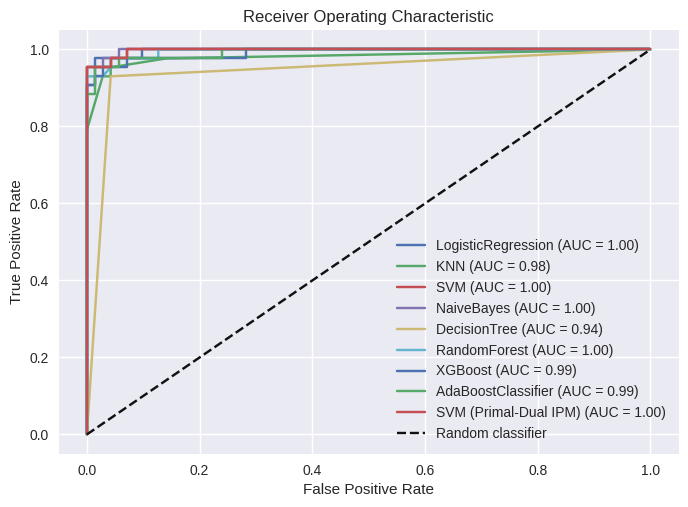

In [22]:
for model,name in zip(models,model_names):
    model.fit(x_train,y_train)
    y_pred_prob = model.predict_proba(x_test)[:, 1]
    fpr,tpr,thresholds = roc_curve(y_test,y_pred_prob)
    auc_score = auc(fpr,tpr)
    auc_scores.append(auc_score)
    plt.plot(fpr, tpr, label='%s (AUC = %0.2f)' % (name, auc_score))

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score
f1_scores = []
recall = []
precision = []

for model, name in zip(models, model_names):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    f1 = f1_score(y_test, y_pred)
    r = recall_score(y_test,y_pred)
    p = precision_score(y_test,y_pred)
    f1_scores.append(f1)
    recall.append(r)
    precision.append(p)
    print('%s: F1-score = %0.3f' % (name, f1))
    print('%s: Precision = %0.3f' % (name, p))
    print('%s: Recall = %0.3f' % (name, r))
    print('\n')




average_f1_score = sum(f1_scores) / len(f1_scores)
print('Average F1-score:', average_f1_score)

LogisticRegression: F1-score = 0.965
LogisticRegression: Precision = 0.976
LogisticRegression: Recall = 0.953


KNN: F1-score = 0.930
KNN: Precision = 0.930
KNN: Recall = 0.930


SVM: F1-score = 0.965
SVM: Precision = 0.976
SVM: Recall = 0.953


NaiveBayes: F1-score = 0.952
NaiveBayes: Precision = 0.976
NaiveBayes: Recall = 0.930


DecisionTree: F1-score = 0.930
DecisionTree: Precision = 0.930
DecisionTree: Recall = 0.930


RandomForest: F1-score = 0.952
RandomForest: Precision = 0.976
RandomForest: Recall = 0.930


XGBoost: F1-score = 0.941
XGBoost: Precision = 0.952
XGBoost: Recall = 0.930


AdaBoostClassifier: F1-score = 0.952
AdaBoostClassifier: Precision = 0.976
AdaBoostClassifier: Recall = 0.930


SVM (Primal-Dual IPM): F1-score = 0.965
SVM (Primal-Dual IPM): Precision = 0.976
SVM (Primal-Dual IPM): Recall = 0.953


Average F1-score: 0.9503224545632205


In [24]:
# Fair head-to-head comparison: IPM SVM vs sklearn SVC with matching kernel hyperparameters and split.
from sklearn.metrics import accuracy_score, confusion_matrix

comparison_models = {
    "Lecture IPM SVM (Linear)": IPMSVM(C=1.0, kernel='linear', tol=1e-8, max_iter=60),
    "sklearn SVC (Linear)": SVC(C=1.0, kernel='linear'),
    "Lecture IPM SVM (RBF)": IPMSVM(C=1.0, kernel='rbf', gamma='scale', tol=1e-8, max_iter=60),
    "sklearn SVC (RBF)": SVC(C=1.0, kernel='rbf', gamma='scale'),
    "Lecture IPM SVM (Poly)": IPMSVM(C=1.0, kernel='poly', gamma='scale', degree=3, coef0=1.0, tol=1e-8, max_iter=60),
    "sklearn SVC (Poly)": SVC(C=1.0, kernel='poly', gamma='scale', degree=3, coef0=1.0),
    "Lecture IPM SVM (Sigmoid)": IPMSVM(C=1.0, kernel='sigmoid', gamma=0.01, coef0=0.0, tol=1e-8, max_iter=60),
    "sklearn SVC (Sigmoid)": SVC(C=1.0, kernel='sigmoid', gamma=0.01, coef0=0.0)
}

comparison_rows = []

print("Confusion Matrix Format:")
print("[[TN FP]")
print(" [FN TP]]")
print("-" * 50)

for comparison_name, comparison_model in comparison_models.items():
    started = time.perf_counter()
    comparison_model.fit(x_train, y_train)
    elapsed = time.perf_counter() - started

    comparison_prediction = comparison_model.predict(x_test)

    cm = confusion_matrix(y_test, comparison_prediction)

    print(f"\n{comparison_name}")
    print(cm)

    comparison_rows.append({
        'Model': comparison_name,
        'Accuracy': accuracy_score(y_test, comparison_prediction),
        'Precision': precision_score(y_test, comparison_prediction, zero_division=0),
        'Recall': recall_score(y_test, comparison_prediction, zero_division=0),
        'F1': f1_score(y_test, comparison_prediction, zero_division=0),
        'Fit time (s)': elapsed,
        'Iterations': getattr(comparison_model, 'n_iter_', np.nan),
        'Converged': getattr(comparison_model, 'converged_', True),
        'Support vectors': getattr(comparison_model, 'n_support_total_', np.nan)
    })

ipm_comparison = pd.DataFrame(comparison_rows).set_index('Model')

display(ipm_comparison.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1': '{:.4f}',
    'Fit time (s)': '{:.4f}'
}))

for kernel_label in ['Linear', 'RBF', 'Poly', 'Sigmoid']:
    ipm_name = f'Lecture IPM SVM ({kernel_label})'
    svc_name = f'sklearn SVC ({kernel_label})'
    print(f'F1 difference {kernel_label} (IPM - SVC): '
          f"{ipm_comparison.loc[ipm_name, 'F1'] - ipm_comparison.loc[svc_name, 'F1']:+.4f}")

print('Note: sklearn SVC uses highly optimized LIBSVM; the educational IPM solves a Newton/KKT system each iteration.')

Confusion Matrix Format:
[[TN FP]
 [FN TP]]
--------------------------------------------------

Lecture IPM SVM (Linear)
[[68  3]
 [ 2 41]]

sklearn SVC (Linear)
[[68  3]
 [ 2 41]]

Lecture IPM SVM (RBF)
[[70  1]
 [ 2 41]]

sklearn SVC (RBF)
[[70  1]
 [ 2 41]]

Lecture IPM SVM (Poly)
[[71  0]
 [ 2 41]]

sklearn SVC (Poly)
[[71  0]
 [ 2 41]]

Lecture IPM SVM (Sigmoid)
[[71  0]
 [ 3 40]]

sklearn SVC (Sigmoid)
[[71  0]
 [ 3 40]]


,Accuracy,Precision,Recall,F1,Fit time (s),Iterations,Converged,Support vectors
Model,,,,,,,,
Lecture IPM SVM (Linear),0.9561,0.9318,0.9535,0.9425,0.4828,27,True,36.000000
sklearn SVC (Linear),0.9561,0.9318,0.9535,0.9425,0.0031,[1092],True,nan
Lecture IPM SVM (RBF),0.9737,0.9762,0.9535,0.9647,0.3262,18,True,105.000000
sklearn SVC (RBF),0.9737,0.9762,0.9535,0.9647,0.0044,[196],True,nan
Lecture IPM SVM (Poly),0.9825,1.0000,0.9535,0.9762,0.3753,19,True,59.000000
sklearn SVC (Poly),0.9825,1.0000,0.9535,0.9762,0.0030,[228],True,nan
Lecture IPM SVM (Sigmoid),0.9737,1.0000,0.9302,0.9639,0.3641,19,True,105.000000
sklearn SVC (Sigmoid),0.9737,1.0000,0.9302,0.9639,0.0043,[104],True,nan


F1 difference Linear (IPM - SVC): +0.0000
F1 difference RBF (IPM - SVC): +0.0000
F1 difference Poly (IPM - SVC): +0.0000
F1 difference Sigmoid (IPM - SVC): +0.0000
Note: sklearn SVC uses highly optimized LIBSVM; the educational IPM solves a Newton/KKT system each iteration.


> We can see that Logistic Regression , SVM and AdaBoost have the best scores so we continue to make models based on this information

# Making Models

In [25]:
from sklearn.model_selection import GridSearchCV

SVM = SVC()

C = [0.1,1,10,100]
kernel = ['linear', 'poly', 'rbf', 'sigmoid']

params = {'C':C,'kernel':kernel}

SVM_grid = GridSearchCV(estimator = SVM,param_grid = params,refit= True,verbose = 0,n_jobs=-1)
SVM_grid.fit(x_train,y_train.ravel())
print(f"best parameters : {SVM_grid.best_params_}")
print(f"best score : {SVM_grid.best_score_}")

best parameters : {'C': 0.1, 'kernel': 'linear'}
best score : 0.9758241758241759


In [26]:
LogReg = LogisticRegression(max_iter=10000)

penalty = ['l1','l2','elasticnet']
solver = [ 'newton-cg', 'lbfgs', 'liblinear', 'sag','saga']
C = [0.001, 0.01, 0.1, 1, 10, 100]

params2 = {'C' : C ,'penalty' : penalty , 'solver' : solver }


LogReg_grid = GridSearchCV(estimator = LogReg,param_grid = params2 ,refit= True,verbose = 0,n_jobs=-1)
LogReg_grid.fit(x_train,y_train.ravel())
print(f"best parameters : {LogReg_grid.best_params_}")
print(f"best score : {LogReg_grid.best_score_}")

best parameters : {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
best score : 0.9780219780219781


In [27]:
# Tune IPM SVM only when its best comparison F1 is within 0.03 of the best sklearn SVC.
# The final test set is NOT used by GridSearchCV; tuning uses 3-fold CV on x_train.
best_ipm_f1 = ipm_comparison.loc[ipm_comparison.index.str.startswith('Lecture IPM SVM'), 'F1'].max()
best_sklearn_svc_f1 = ipm_comparison.loc[ipm_comparison.index.str.startswith('sklearn SVC'), 'F1'].max()
ipm_is_competitive = best_ipm_f1 >= best_sklearn_svc_f1 - 0.03

if ipm_is_competitive:
    ipm_param_grid = [
        {'kernel': ['linear'], 'C': [0.1, 1.0, 10.0]},
        {'kernel': ['rbf'], 'C': [0.1, 1.0, 10.0], 'gamma': ['scale', 0.01, 0.1]},
        {'kernel': ['poly'], 'C': [0.1, 1.0, 10.0], 'gamma': ['scale', 0.01], 'degree': [2, 3], 'coef0': [0.0, 1.0]},
        {'kernel': ['sigmoid'], 'C': [0.1, 1.0, 10.0], 'gamma': [0.001, 0.005, 0.01], 'coef0': [0.0, 1.0]}
    ]
    ipm_grid = GridSearchCV(
        IPMSVM(tol=1e-8, max_iter=50),
        param_grid=ipm_param_grid,
        scoring='f1', cv=3, n_jobs=1, refit=True, verbose=1
    )
    ipm_grid.fit(x_train, y_train)
    tuned_ipm_svm = ipm_grid.best_estimator_
    tuned_ipm_prediction = tuned_ipm_svm.predict(x_test)
    print('Best IPM parameters:', ipm_grid.best_params_)
    print(f'Best mean CV F1: {ipm_grid.best_score_:.4f}')
    print(f'Tuned IPM test accuracy: {accuracy_score(y_test, tuned_ipm_prediction):.4f}')
    print(f'Tuned IPM test F1: {f1_score(y_test, tuned_ipm_prediction):.4f}')
    print(f'IPM iterations: {tuned_ipm_svm.n_iter_}; converged: {tuned_ipm_svm.converged_}')
else:
    print('IPM tuning skipped: its F1 is more than 0.03 below sklearn SVC.')


Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best IPM parameters: {'C': 1.0, 'coef0': 1.0, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}
Best mean CV F1: 0.9711
Tuned IPM test accuracy: 0.9825
Tuned IPM test F1: 0.9762
IPM iterations: 19; converged: True


# The final Model

> As we can see Logistic Regression was the best and most efficient model so we use it as the final model

accuracy  : 0.9912280701754386 

f1 score  : 0.9882352941176471 

classification report :
               precision    recall  f1-score   support

           0       0.99      1.00      0.99        71
           1       1.00      0.98      0.99        43

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114
 

The Confusion Matrix : 



0.9912280701754386

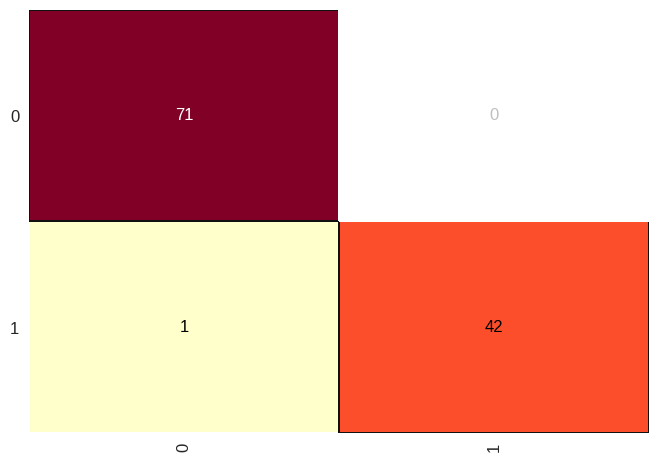

In [28]:
LogReg = LogisticRegression(solver='liblinear' , C = 0.1 , penalty = 'l2')
LogReg.fit(x_train,y_train.ravel())
y_pred = LogReg.predict(x_test)

print(f"accuracy  : {metrics.accuracy_score(y_test,y_pred)} \n")
print(f"f1 score  : {metrics.f1_score(y_test,y_pred)} \n")
print(f"classification report :\n {metrics.classification_report(y_test,y_pred)} \n")
print('The Confusion Matrix : \n')
cm = ConfusionMatrix(LogReg)
cm.fit(x_train,y_train)
cm.score(x_test,y_test)